# Cleaned PyTorch Hazard Model

In [101]:
# load libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import pyhere as here
from sklearn.preprocessing import StandardScaler
from lifelines.utils import concordance_index



In [52]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## Clinical Metadata Preprocessing
### Load Data

In [53]:
### Load data 

# load clinical metadata
clinical = pd.read_csv(here.here("data", "processed","clinical_data.csv"))


In [54]:
import pandas as pd
pd.set_option('display.max_columns', None)

# overview of our clinical data
clinical.head()

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,er_status,neoplasm_histologic_grade,her2_status_measured_by_snp6,her2_status,tumor_other_histologic_subtype,hormone_therapy,inferred_menopausal_state,integrative_cluster,primary_tumor_laterality,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,oncotree_code,overall_survival_months,overall_survival,pr_status,radio_therapy,3-gene_classifier_subtype,tumor_size,tumor_stage,death_from_cancer
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Post,4ER+,Right,10.0,NaN,6.044,IDC,140.500000,1,Negative,1,ER-/HER2-,22.0,2.0,Living
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Pre,4ER+,Right,0.0,2.0,4.020,IDC,84.633333,1,Positive,1,ER+/HER2- High Prolif,10.0,1.0,Living
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Ductal/NST,1,Pre,3,Right,1.0,2.0,4.030,IDC,163.700000,0,Positive,0,unknown,15.0,2.0,Died of Disease
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Mixed,1,Pre,9,Right,3.0,1.0,4.050,MDLC,164.933333,1,Positive,1,unknown,25.0,2.0,Living
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Mixed,1,Post,9,Right,8.0,2.0,6.080,MDLC,41.366667,0,Positive,1,ER+/HER2- High Prolif,40.0,2.0,Died of Disease


In [55]:
# define outcome variables
df = clinical.copy()
time_col = "overall_survival_months"
event_col = "death_from_cancer"

# 'event' will be 1 if died of cancer of disease, 0 otherwise (including died of other causes or alive)
df["event"] = (df[event_col] == "Died of Disease").astype(int)
df["time"] = df[time_col]


In [56]:
df["event"].value_counts()

event
0    1282
1     622
Name: count, dtype: int64

In [57]:
df.head()

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,er_status,neoplasm_histologic_grade,her2_status_measured_by_snp6,her2_status,tumor_other_histologic_subtype,hormone_therapy,inferred_menopausal_state,integrative_cluster,primary_tumor_laterality,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,oncotree_code,overall_survival_months,overall_survival,pr_status,radio_therapy,3-gene_classifier_subtype,tumor_size,tumor_stage,death_from_cancer,event,time
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Post,4ER+,Right,10.0,NaN,6.044,IDC,140.500000,1,Negative,1,ER-/HER2-,22.0,2.0,Living,0,140.500000
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Pre,4ER+,Right,0.0,2.0,4.020,IDC,84.633333,1,Positive,1,ER+/HER2- High Prolif,10.0,1.0,Living,0,84.633333
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Ductal/NST,1,Pre,3,Right,1.0,2.0,4.030,IDC,163.700000,0,Positive,0,unknown,15.0,2.0,Died of Disease,1,163.700000
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Mixed,1,Pre,9,Right,3.0,1.0,4.050,MDLC,164.933333,1,Positive,1,unknown,25.0,2.0,Living,0,164.933333
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Mixed,1,Post,9,Right,8.0,2.0,6.080,MDLC,41.366667,0,Positive,1,ER+/HER2- High Prolif,40.0,2.0,Died of Disease,1,41.366667


In [58]:
# group rare cancer types into "Other" category
# This will make one hot encoding and modeling more robust by reducing the number of categories with very few samples
rare_threshold = 50

value_counts = df["cancer_type_detailed"].value_counts()

rare_classes = value_counts[value_counts < rare_threshold].index

df["cancer_type_detailed_clean"] = df["cancer_type_detailed"].replace(
    rare_classes, "Other"
)

# do same for histologic subtype
value_counts = df["tumor_other_histologic_subtype"].value_counts()

rare_classes = value_counts[value_counts < rare_threshold].index

df["tumor_other_histologic_subtype_clean"] = df["tumor_other_histologic_subtype"].replace(
    rare_classes, "Other"
)

In [59]:
# Drop identifiers, outcome columns, and pre-modified columns from clinical features
drop_cols = [
    # original columns to drop
    "patient_id",
    "cancer_type",
    "cohort",
    "cancer_type_detailed",
    "er_status_measured_by_ihc",
    "her2_status_measured_by_snp6",
    "tumor_other_histologic_subtype",
    "integrative_cluster",
    "oncotree_code",
    "radio_therapy",
    "chemotherapy",
    "type_of_breast_surgery",
    "hormone_therapy", 
    "overall_survival",
    # updated drop columns 
    "nottingham_prognostic_index",  # composite of existing features
    "3-gene_classifier_subtype",    # derived from ER/PR/HER2
    "tumor_other_histologic_subtype_clean",  # redundant with cancer_type_detailed
    
    time_col,
    event_col
]

# X will now contain only clinical features that will go into model training
X = df.drop(columns=drop_cols + ["event", "time"])
y_time = df["time"].values
y_event = df["event"].values

#### Identify feature types

In [60]:
# different data types in clinical data
X.dtypes.value_counts()

object     9
float64    5
Name: count, dtype: int64

In [61]:
# identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

# fill missing categorical data with "Unknown"
X[categorical_cols] = X[categorical_cols].fillna("Unknown")

In [62]:
numeric_cols

['age_at_diagnosis',
 'neoplasm_histologic_grade',
 'lymph_nodes_examined_positive',
 'mutation_count',
 'tumor_size']

In [63]:
categorical_cols

['cellularity',
 'pam50_+_claudin-low_subtype',
 'er_status',
 'her2_status',
 'inferred_menopausal_state',
 'primary_tumor_laterality',
 'pr_status',
 'tumor_stage',
 'cancer_type_detailed_clean']

#### Train/Validation Split 

In [64]:
from sklearn.model_selection import train_test_split

# First split off test set (hold this out entirely until the end)
X_train, X_test, time_train, time_test, event_train, event_test = train_test_split(
    X, y_time, y_event,
    test_size=0.15,
    stratify=y_event,
    random_state=42
)

In [65]:
X_train

,age_at_diagnosis,cellularity,pam50_+_claudin-low_subtype,er_status,neoplasm_histologic_grade,her2_status,inferred_menopausal_state,primary_tumor_laterality,lymph_nodes_examined_positive,mutation_count,pr_status,tumor_size,tumor_stage,cancer_type_detailed_clean
1292,79.26,Moderate,Normal,Positive,1.0,Negative,Post,Left,0.0,8.0,Negative,48.0,2.0,Breast Invasive Lobular Carcinoma
1782,71.05,High,LumA,Positive,2.0,Positive,Post,Left,0.0,5.0,Positive,21.0,unknown,Unknown
171,48.07,High,claudin-low,Positive,2.0,Negative,Pre,Unknown,14.0,4.0,Positive,28.0,2.0,Breast Invasive Ductal Carcinoma
808,73.91,High,Her2,Positive,3.0,Negative,Post,Right,1.0,7.0,Negative,18.0,2.0,Breast Invasive Ductal Carcinoma
864,47.29,High,LumA,Positive,2.0,Negative,Pre,Right,0.0,4.0,Positive,15.0,1.0,Breast Invasive Ductal Carcinoma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1278,55.53,Moderate,LumA,Positive,1.0,Negative,Post,Right,0.0,7.0,Positive,15.0,1.0,Breast Invasive Ductal Carcinoma
450,60.62,Moderate,LumA,Positive,1.0,Negative,Post,Right,4.0,3.0,Positive,8.0,2.0,Breast Invasive Ductal Carcinoma
1676,69.94,High,claudin-low,Negative,3.0,Negative,Post,Right,0.0,2.0,Negative,24.0,unknown,Breast Invasive Ductal Carcinoma
530,56.79,Low,Basal,Negative,3.0,Negative,Post,Left,0.0,7.0,Negative,16.0,1.0,Breast Invasive Ductal Carcinoma


#### Process numeric features for training and validation set separately
Scaling/imputation depends on the data that we see, so we must normalize the data separately for training and validation to prevent data leakage

In [66]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_num = num_imputer.fit_transform(X_train[numeric_cols])
X_train_num = scaler.fit_transform(X_train_num)

X_test_num = num_imputer.transform(X_test[numeric_cols])
X_test_num = scaler.transform(X_test_num)

#### Process categorical features separately 
One-hot encode separately

In [67]:
X_train_cat = pd.get_dummies(
    X_train[categorical_cols],
    drop_first=True
).astype(float)

X_test_cat = pd.get_dummies(
    X_test[categorical_cols],
    drop_first=True
).astype(float)

X_test_cat = X_test_cat.reindex(
    columns=X_train_cat.columns,
    fill_value=0
)

#### Combine features

In [68]:
import numpy as np

X_train_final = np.hstack([
    X_train_num.astype(np.float32),
    X_train_cat.values.astype(np.float32)
])

X_test_final = np.hstack([
    X_test_num.astype(np.float32),
    X_test_cat.values.astype(np.float32)
])

In [69]:
X_train_final.shape

(1618, 29)

#### Convert to PyTorch Tensors

In [70]:
import torch

X_train_tensor = torch.tensor(X_train_final, dtype=torch.float32)
time_train_tensor = torch.tensor(time_train, dtype=torch.float32)
event_train_tensor = torch.tensor(event_train, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_final, dtype=torch.float32)
time_test_tensor = torch.tensor(time_test, dtype=torch.float32)
event_test_tensor = torch.tensor(event_test, dtype=torch.float32)


## Add Expression Data

In [76]:
# Load expression data
expression_data = pd.read_csv(here.here("data", "processed", "expression_data.csv"))

# Check structure
print(expression_data.shape)
#print(expression_data.head(2))
print("Patient ID column:", expression_data.columns[0])  # confirm index column name

(1904, 489)
Patient ID column: brca1


In [77]:
# Check if rows are already in the same order as df
print(f"Expression rows: {expression_data.shape[0]}")
print(f"Clinical rows: {df.shape[0]}")

# Since there's no patient_id column, align by position using df's integer index
# First reset df index to confirm it's 0-based
print(df.index[:5])
print(expression_data.index[:5])

Expression rows: 1904
Clinical rows: 1904
RangeIndex(start=0, stop=5, step=1)
RangeIndex(start=0, stop=5, step=1)


#### Align Expression Data with Clinical Data

In [86]:
# Get positional locations of each split
train_pos = df.index.get_indexer(X_train.index)
test_pos  = df.index.get_indexer(X_test.index)

# Split expression data by position
expr_train = expression_data.iloc[train_pos].values.astype(np.float32)
expr_test  = expression_data.iloc[test_pos].values.astype(np.float32)

print(f"Train: {expr_train.shape}, Test: {expr_test.shape}")

Train: (1618, 489), Test: (286, 489)


### Normalize Expression Data
Microarray Expression data is already Z-scaled (mean expression of a gene = 0, std = 1). 

However, because we've split data into training, validation, and test sets, this consitutes data leakage, because the dataset was normalized/scaled based on the full dataset. 

Therefore, we will now re-normalize the expression data for each split

In [87]:
# Check if already well-normalized
print("Mean per gene (should be ~0):", expression_data.mean(axis=0).describe())
print("Std per gene (should be ~1):",  expression_data.std(axis=0).describe())

Mean per gene (should be ~0): count    4.890000e+02
mean    -4.188792e-09
std      7.362847e-07
min     -2.678571e-06
25%     -4.726891e-07
50%     -5.252101e-08
75%      5.252101e-07
max      2.258403e-06
dtype: float64
Std per gene (should be ~1): count    4.890000e+02
mean     1.000263e+00
std      6.548091e-07
min      1.000261e+00
25%      1.000262e+00
50%      1.000263e+00
75%      1.000263e+00
max      1.000265e+00
dtype: float64


In [88]:
from sklearn.preprocessing import StandardScaler
# StandardScaler will standardize each gene to have mean=0 and std=1 based on training data stats, then apply same transformation to val/test

expr_scaler = StandardScaler()
expr_train = expr_scaler.fit_transform(expr_train)
expr_test  = expr_scaler.transform(expr_test)

expr_train_tensor = torch.tensor(expr_train, dtype=torch.float32)
expr_test_tensor  = torch.tensor(expr_test,  dtype=torch.float32)

print(f"Expression input dim: {expr_train_tensor.shape[1]}")

Expression input dim: 489


# Adding Mutation data

In [85]:
# Load mutation data
mutation_binary = pd.read_csv(here.here("data", "processed", "mutation_binary_data.csv"))
mutation_classified = pd.read_csv(here.here("data", "processed", "mutation_classified_data.csv"))

# Check structure of both
print("Binary mutation shape:", mutation_binary.shape)
#print(mutation_binary.head(2))
print("\nFirst column name:", mutation_binary.columns[0])

print("\n---")

print("Classified mutation shape:", mutation_classified.shape)
# print(mutation_classified.head(2))
print("\nFirst column name:", mutation_classified.head)

Binary mutation shape: (1904, 173)

First column name: pik3ca_mut

---
Classified mutation shape: (1904, 173)

First column name: <bound method NDFrame.head of      pik3ca_mut  tp53_mut muc16_mut ahnak2_mut kmt2c_mut syne1_mut  \
0            WT        WT        WT         WT        WT        WT   
1            WT  Missense        WT         WT        WT        WT   
2      Missense        WT        WT         WT        WT        WT   
3      Missense        WT        WT         WT        WT        WT   
4            WT  Missense        WT         WT        WT        WT   
...         ...       ...       ...        ...       ...       ...   
1899   Missense        WT        WT         WT        WT        WT   
1900         WT  Missense        WT         WT        WT        WT   
1901         WT        WT        WT         WT        WT        WT   
1902         WT        WT        WT   Missense        WT        WT   
1903         WT        WT        WT         WT        WT        WT   


In [29]:
# Check what mutation types exist
print(mutation_classified.iloc[:, 0:5].apply(lambda x: x.unique()))

# Check sparsity of binary data — what fraction of entries are mutated?
print(f"\nMutation rate per gene (mean):")
print(mutation_binary.mean().describe())
print(f"\nTotal mutations per patient (mean):")
print(mutation_binary.sum(axis=1).describe())

pik3ca_mut    [WT, Missense, Other, Frameshift, Deletion, In...
tp53_mut      [WT, Missense, Frameshift, Nonsense, Other, De...
muc16_mut     [WT, Missense, Nonsense, Deletion, Other, Fram...
ahnak2_mut          [WT, Missense, Nonsense, Other, Frameshift]
kmt2c_mut     [WT, Frameshift, Nonsense, Missense, Other, De...
dtype: object

Mutation rate per gene (mean):
count    173.000000
mean       0.029567
std        0.047979
min        0.000525
25%        0.007353
50%        0.015756
75%        0.030987
max        0.417542
dtype: float64

Total mutations per patient (mean):
count    1904.000000
mean        5.115021
std         3.351521
min         0.000000
25%         3.000000
50%         5.000000
75%         7.000000
max        48.000000
dtype: float64


## Mutation Approach

##### Due to sparsity of the mutation information, we will build: 
### 1. Binary Mutation Matrix
### 2. Severity-weighted matrix
### 3. Tumor mutational burden matrix

#### And concatenate these features as input into a single mutation encoder

In [89]:
# Check mutation type categories across all genes
all_values = pd.unique(mutation_classified.values.ravel())
print("All mutation categories:", sorted(all_values))

All mutation categories: ['Deletion', 'Frameshift', 'Insertion', 'Missense', 'Nonsense', 'Other', 'WT']


3 complementary feature sets:

In [90]:
# Option A: TMB only (1 feature) — simplest possible mutation signal
tmb_only = mutation_binary.sum(axis=1).values.astype(np.float32).reshape(-1, 1)

# Option B: Top mutated genes only — keep genes mutated in >5% of patients
mutation_freq = mutation_binary.mean(axis=0)
frequent_genes = mutation_freq[mutation_freq > 0.05].index
print(f"Genes mutated in >5% of patients: {len(frequent_genes)}")
print(frequent_genes.tolist())

mut_frequent = mutation_binary[frequent_genes].values.astype(np.float32)
print(f"Frequent mutation matrix shape: {mut_frequent.shape}")

Genes mutated in >5% of patients: 25
['pik3ca_mut', 'tp53_mut', 'muc16_mut', 'ahnak2_mut', 'kmt2c_mut', 'syne1_mut', 'gata3_mut', 'map3k1_mut', 'ahnak_mut', 'dnah11_mut', 'cdh1_mut', 'dnah2_mut', 'kmt2d_mut', 'ush2a_mut', 'ryr2_mut', 'dnah5_mut', 'herc2_mut', 'pde4dip_mut', 'akap9_mut', 'tg_mut', 'birc6_mut', 'utrn_mut', 'tbx3_mut', 'col6a3_mut', 'arid1a_mut']
Frequent mutation matrix shape: (1904, 25)


## Rethinking models

### Given inconsistency of expression encoder/ expression autoencoder results and poor performance of mutation encoder, we will try two new strategies: 

### 1. Add mutation features directly to clinical encoder
### 2. Cross-validation and comparison of expression encoder and autoencoder

## 1. Creating combined clinical + mutation encoder

In [93]:
# Get frequent mutation features split by position
mut_frequent_vals = mutation_binary[frequent_genes].values.astype(np.float32)

mut_freq_train = mut_frequent_vals[train_pos]
mut_freq_test  = mut_frequent_vals[test_pos]

# Add TMB as well — scale it since it's a count variable
from sklearn.preprocessing import StandardScaler

tmb_vals = mutation_binary.sum(axis=1).values.astype(np.float32).reshape(-1, 1)
tmb_train = tmb_vals[train_pos]
tmb_test  = tmb_vals[test_pos]

tmb_scaler = StandardScaler()
tmb_train = tmb_scaler.fit_transform(tmb_train)
tmb_test  = tmb_scaler.transform(tmb_test)

# Combine clinical + frequent mutations + TMB into one feature vector
X_train_aug = np.hstack([X_train_final, mut_freq_train, tmb_train])
X_test_aug  = np.hstack([X_test_final,  mut_freq_test,  tmb_test])

print(f"Augmented clinical shape: {X_train_aug.shape}")
# Was (1294, 29), now (1294, 55) — 29 clinical + 25 mutations + 1 TMB



Augmented clinical shape: (1618, 55)


In [95]:
# Convert to tensors
X_train_aug_tensor = torch.tensor(X_train_aug, dtype=torch.float32)
X_test_aug_tensor  = torch.tensor(X_test_aug,  dtype=torch.float32)

# Change augmented tensors to original variable for training
X_train_tensor = X_train_aug_tensor
X_test_tensor = X_test_aug_tensor

# Change augmented final matrices to original variable for training 
X_train_final = X_train_aug
X_test_final = X_test_aug

## Next: Add mutation information to clinical features

In [97]:
# Rebuild X_raw cleanly as pure numpy
num_imputer_raw = SimpleImputer(strategy="median")
X_num_raw = num_imputer_raw.fit_transform(X[numeric_cols].values)

X_cat_raw = pd.get_dummies(
    X[categorical_cols].fillna("Unknown"),
    drop_first=True
).values.astype(np.float32)

X_raw = np.hstack([
    X_num_raw.astype(np.float32),
    X_cat_raw
])

print(f"X_raw shape: {X_raw.shape}")
print(f"X_raw dtype: {X_raw.dtype}")
# Should be float32 with no NaNs
print(f"NaNs in X_raw: {np.isnan(X_raw).sum()}")

X_raw shape: (1904, 29)
X_raw dtype: float32
NaNs in X_raw: 0


In [98]:
# Use the already-cleaned X_raw from the cell above
# (with num_imputer_raw applied — no NaNs)
# Just need to rebuild with get_dummies using fillna for categoricals

X_cat_raw = pd.get_dummies(
    X[categorical_cols].fillna("Unknown"),
    drop_first=True
).values.astype(np.float32)

X_raw = np.hstack([
    X_num_raw.astype(np.float32),  # already imputed above
    X_cat_raw
])

print(f"X_raw shape: {X_raw.shape}")
print(f"NaNs in X_raw: {np.isnan(X_raw).sum()}")
# Must be 0 before proceeding

X_raw shape: (1904, 29)
NaNs in X_raw: 0


In [99]:
# ── Step 1: Build augmented clinical + mutation feature matrix ────

# Frequent mutation genes (mutated in >5% of patients)
mut_frequent_raw = mutation_binary[frequent_genes].values.astype(np.float32)

# TMB (raw counts — scaling happens inside CV)
tmb_raw = mutation_binary.sum(axis=1).values.astype(np.float32).reshape(-1, 1)

# Augmented raw feature matrix: clinical + frequent mutations + TMB
X_raw_mut = np.hstack([X_raw, mut_frequent_raw, tmb_raw])

print(f"Clinical only shape:      {X_raw.shape}")
print(f"Augmented + mut shape:    {X_raw_mut.shape}")
print(f"NaNs in X_raw_mut:        {np.isnan(X_raw_mut).sum()}")
# Expected: (1904, 55) — 29 clinical + 25 mutations + 1 TMB

Clinical only shape:      (1904, 29)
Augmented + mut shape:    (1904, 55)
NaNs in X_raw_mut:        0


## Helper Functions

#### Cox partial likelihood loss


    The samples are first sorted in descending order of survival time to
    construct the appropriate risk sets. The loss is computed as:

        L = -1/E * Σ_i δ_i [r_i - log(Σ_{j∈R_i} exp(r_j))]

    where:
        - E is the total number of observed events,
        - δ_i is the event indicator for sample i,
        - r_i is the predicted log-risk score,
        - R_i is the set of individuals at risk at time t_i.

    This implementation assumes that ``risk``, ``time``, and ``event`` are
    PyTorch tensors located on the same device.

In [105]:
def cox_loss(risk, time, event):
    """
    Compute the negative Cox proportional hazards partial log-likelihood loss.

    This loss function is commonly used to train survival models under the
    Cox Proportional Hazards framework. It compares the predicted risk scores
    of individuals who experienced an event to the set of individuals still
    at risk at the corresponding event times. The implementation uses the
    Breslow approximation for tied event times and leverages
    ``torch.logcumsumexp`` for numerical stability.

    Parameters
    ----------
    risk : torch.Tensor
        One-dimensional tensor of predicted log-risk scores (higher values
        indicate greater hazard) with shape ``(n_samples,)``.

    time : torch.Tensor
        One-dimensional tensor containing observed survival or follow-up
        times for each sample with shape ``(n_samples,)``.

    event : torch.Tensor
        One-dimensional binary tensor indicating event status for each sample,
        where ``1`` denotes that the event occurred and ``0`` denotes a
        right-censored observation.

    Returns
    -------
    torch.Tensor
        Scalar tensor representing the mean negative partial log-likelihood,
        normalized by the number of observed events. Lower values indicate
        better agreement between predicted risks and observed event ordering.
    """
    order = torch.argsort(time, descending=True)
    risk = risk[order]
    event = event[order]

    log_cumsum = torch.logcumsumexp(risk, dim=0)
    loss = -torch.sum((risk - log_cumsum) * event) / event.sum()
    return loss

def compute_cindex(model, X_tensor, time_array, event_array):
    """
    Compute the concordance index for a PyTorch model.
    
    Parameters:
        model : torch.nn.Module
            Trained survival model that outputs risk scores
        X_tensor : torch.Tensor
            Input features
        time_array : np.array
            Survival times
        event_array : np.array
            Event indicator (1=event, 0=censored)
            
    Returns:
        c_index : float
            Concordance index
    """
    model.eval()
    with torch.no_grad():
        risk_scores = model(X_tensor).numpy()
    
    return concordance_index(time_array, -risk_scores, event_array)

## Create Survival-Aware Autoencoder

#### To optimize final results, we will try expanding our autoencoder in 2 ways: 
##### 1. Survival-aware autoencoder pretraining
Instead of pure reconstruction loss, pretrain the AE with combined loss of reconstruction (stander AE loss) + smaller Cox survival loss. This pushes the autoencoder to encode survival-relevant variation instead of just expression variance. 
##### 2. Larger latent dimension 
Current latent dims = 16, we will increase this to 32 so the autoencoder has more dimensions to encode variation

In [108]:
X_train_final.shape[1]

55

In [ ]:
# ── Survival-aware Autoencoder ────────────────────────────────────

class SurvivalAwareAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=32):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, latent_dim),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim)
        )

        # Small survival head attached to latent space
        # Guides the encoder to preserve survival-relevant variation
        self.survival_head = nn.Linear(latent_dim, 1)

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        risk = self.survival_head(z).squeeze(-1)
        return x_recon, z, risk
    
# ── Updated survival model using new AE ──────────────────────────

class ClinicalExprSurvAESurvNet(nn.Module):
    """
    Same architecture as ClinicalExprAESurvNet but accepts
    the larger latent_dim=32 encoder output.
    """
    def __init__(self, clin_dim, pretrained_encoder, latent_dim=32):
        super().__init__()

        # clinical encoder
        self.clin_enc = nn.Sequential(
            nn.Linear(clin_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # pretrained expression autoencoder
        self.expr_enc = pretrained_encoder

        # Fusion encoder 
        # 55 (clin) + latent_dim (expr) → fusion
        self.head = nn.Sequential(
            nn.Linear(16 + latent_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x_clin, x_expr):
        z_clin = self.clin_enc(x_clin)
        z_expr = self.expr_enc(x_expr)
        z = torch.cat([z_clin, z_expr], dim=1)
        return self.head(z).squeeze(-1)

In [ ]:
# ── Survival-aware Autoencoder ────────────────────────────────────

class SurvivalAwareAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=32):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, latent_dim),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim)
        )

        # Small survival head attached to latent space
        # Guides the encoder to preserve survival-relevant variation
        self.survival_head = nn.Linear(latent_dim, 1)

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        risk = self.survival_head(z).squeeze(-1)
        return x_recon, z, risk

# Define loss function first
recon_fn = nn.MSELoss()

expr_dim = X_train_final.shape[1]
# First measure the natural scale of each loss before training
ae_test = SurvivalAwareAutoencoder(input_dim=expr_dim, latent_dim=64)
ae_test.eval()
with torch.no_grad():
    recon_test, _, risk_test = ae_test(expr_train_tensor)
    r_loss = recon_fn(recon_test, expr_train_tensor).item()
    s_loss = cox_loss(risk_test, time_train_tensor, event_train_tensor).item()

print(f"Initial recon loss: {r_loss:.4f}")
print(f"Initial surv loss:  {s_loss:.4f}")
print(f"Natural ratio:      {s_loss/r_loss:.2f}x")

# Set weight to compensate for the scale difference
# We want surv to contribute ~5% of total loss
surv_weight = 0.05 * (r_loss / s_loss)
print(f"Corrected surv_weight: {surv_weight:.4f}")


# ── Pretraining with combined loss ───────────────────────────────
set_seed(42)

print("Pretraining survival-aware autoencoder (latent_dim=32)...")

expr_dim  = expr_train_tensor.shape[1]
ae_surv   = SurvivalAwareAutoencoder(input_dim=expr_dim, latent_dim=64)
ae_opt    = torch.optim.Adam(ae_surv.parameters(), lr=1e-3, weight_decay=1e-4)
recon_fn  = nn.MSELoss()

# Survival weight — start small so reconstruction drives learning
# then the latent space gradually becomes survival-aware

#surv_weight      = 0.1   # set above
best_val_recon   = float('inf')
best_ae_weights  = None
ae_patience      = 30
ae_no_improve    = 0
best_combined = 0

for epoch in range(500):
    ae_surv.train()
    ae_opt.zero_grad()

    recon, z, risk = ae_surv(expr_train_tensor)

    recon_loss = recon_fn(recon, expr_train_tensor)
    surv_loss  = cox_loss(risk, time_train_tensor, event_train_tensor)

    # Warmup: no survival loss for first 100 epochs
    # then linearly ramp up to corrected weight over next 100 epochs
    if epoch < 100:
        effective_weight = 0.0
    elif epoch < 200:
        effective_weight = surv_weight * (epoch - 100) / 100
    else:
        effective_weight = surv_weight

    total_loss = recon_loss + effective_weight * surv_loss
    total_loss.backward()
    ae_opt.step()

    if epoch % 10 == 0:
        ae_surv.eval()
        with torch.no_grad():
            val_recon, _, val_risk = ae_surv(expr_val_tensor)
            val_recon_loss = recon_fn(val_recon, expr_val_tensor).item()
            val_ci = concordance_index(
                time_val, -val_risk.numpy(), event_val
            )

        # Stop on val C-index rather than reconstruction
        # Target: val C-index between 0.58-0.65 with low recon loss
        combined_score = val_ci - val_recon_loss  # balance both

        if combined_score > best_combined:
            best_combined   = combined_score
            best_ae_weights = {k: v.clone() for k, v in ae_surv.state_dict().items()}
            ae_no_improve   = 0
        else:
            ae_no_improve  += 1

        if ae_no_improve >= ae_patience:
            print(f"  Early stopping at epoch {epoch}")
            break

        if epoch % 50 == 0:
            print(f"  Epoch {epoch:>4} | "
                  f"Recon: {recon_loss.item():.4f} | "
                  f"Surv:  {surv_loss.item():.4f} | "
                  f"Val recon: {val_recon_loss:.4f} | "
                  f"Val C-index: {val_ci:.4f}")

ae_surv.load_state_dict(best_ae_weights)
print(f"\nBest val reconstruction loss: {best_val_recon:.4f}")


# ── Verify latent space has survival signal ───────────────────────
ae_surv.eval()
with torch.no_grad():
    _, _, train_risk_ae = ae_surv(expr_train_tensor)
    _, _, val_risk_ae   = ae_surv(expr_val_tensor)

latent_train_ci = concordance_index(
    time_train, -train_risk_ae.numpy(), event_train
)
latent_val_ci = concordance_index(
    time_val, -val_risk_ae.numpy(), event_val
)
print(f"Latent space C-index (train): {latent_train_ci:.4f}")
print(f"Latent space C-index (val):   {latent_val_ci:.4f}")
# A val C-index > 0.55 confirms the latent space captured survival signal


# ── Updated survival model using new AE ──────────────────────────

class ClinicalExprSurvAESurvNet(nn.Module):
    """
    Same architecture as ClinicalExprAESurvNet but accepts
    the larger latent_dim=32 encoder output.
    """
    def __init__(self, clin_dim, pretrained_encoder, latent_dim=32):
        super().__init__()

        # clinical encoder
        self.clin_enc = nn.Sequential(
            nn.Linear(clin_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # pretrained expression autoencoder
        self.expr_enc = pretrained_encoder

        # Fusion encoder 
        # 55 (clin) + latent_dim (expr) → fusion
        self.head = nn.Sequential(
            nn.Linear(16 + latent_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x_clin, x_expr):
        z_clin = self.clin_enc(x_clin)
        z_expr = self.expr_enc(x_expr)
        z = torch.cat([z_clin, z_expr], dim=1)
        return self.head(z).squeeze(-1)


# ── Phase 1: frozen encoder ───────────────────────────────────────
model_surv_ae = ClinicalExprSurvAESurvNet(
    clin_dim=X_train_tensor.shape[1],
    pretrained_encoder=ae_surv.encoder,
    latent_dim=64
)

for param in model_surv_ae.expr_enc.parameters():
    param.requires_grad = False

optimizer_p1 = torch.optim.Adam([
    {"params": model_surv_ae.clin_enc.parameters(), "lr": 1e-3},
    {"params": model_surv_ae.head.parameters(),     "lr": 1e-3}
], weight_decay=1e-3)

best_val_cindex   = 0
patience          = 50
epochs_no_improve = 0
best_weights      = None

print("\nPhase 1: Training with frozen encoder...")

for epoch in range(500):
    model_surv_ae.train()
    optimizer_p1.zero_grad()
    risk = model_surv_ae(X_train_tensor, expr_train_tensor)
    loss = cox_loss(risk, time_train_tensor, event_train_tensor)
    loss.backward()
    optimizer_p1.step()

    if epoch % 10 == 0:
        val_ci = compute_cindex(
            model_surv_ae, time_val, event_val,
            X_val_tensor, expr_val_tensor
        )
        if val_ci > best_val_cindex:
            best_val_cindex   = val_ci
            best_weights      = {
                k: v.clone() for k, v in model_surv_ae.state_dict().items()
            }
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"  Early stopping at epoch {epoch}")
            break

        if epoch % 100 == 0:
            print(f"  Epoch {epoch} | Val C-index: {val_ci:.4f}")

model_surv_ae.load_state_dict(best_weights)
print(f"Phase 1 best val C-index: {best_val_cindex:.4f}")


# ── Phase 2: unfreeze and fine-tune ──────────────────────────────
for param in model_surv_ae.expr_enc.parameters():
    param.requires_grad = True

optimizer_p2 = torch.optim.Adam([
    {"params": model_surv_ae.clin_enc.parameters(), "lr": 1e-4},
    {"params": model_surv_ae.expr_enc.parameters(), "lr": 1e-5},
    {"params": model_surv_ae.head.parameters(),     "lr": 1e-4}
], weight_decay=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2, mode='max', factor=0.5, patience=20, min_lr=1e-7
)

best_val_cindex_ft = best_val_cindex
patience           = 100
epochs_no_improve  = 0

print("\nPhase 2: Fine-tuning all layers...")

for epoch in range(2000):
    model_surv_ae.train()
    optimizer_p2.zero_grad()
    risk = model_surv_ae(X_train_tensor, expr_train_tensor)
    loss = cox_loss(risk, time_train_tensor, event_train_tensor)
    loss.backward()
    optimizer_p2.step()

    if epoch % 10 == 0:
        val_ci = compute_cindex(
            model_surv_ae, time_val, event_val,
            X_val_tensor, expr_val_tensor
        )
        scheduler.step(val_ci)

        if val_ci > best_val_cindex_ft:
            best_val_cindex_ft = val_ci
            best_weights       = {
                k: v.clone() for k, v in model_surv_ae.state_dict().items()
            }
            epochs_no_improve  = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"  Early stopping at epoch {epoch}")
            break

        if epoch % 100 == 0:
            lr = optimizer_p2.param_groups[0]['lr']
            print(f"  Epoch {epoch} | "
                  f"Val C-index: {val_ci:.4f} | "
                  f"LR: {lr:.2e}")

model_surv_ae.load_state_dict(best_weights)
print(f"Phase 2 best val C-index: {best_val_cindex_ft:.4f}")


# ── Evaluate and compare ──────────────────────────────────────────
model_surv_ae.eval()
with torch.no_grad():
    train_risk_surv_ae = model_surv_ae(
        X_train_tensor, expr_train_tensor
    ).numpy()

val_results_surv_ae = evaluate_model(
    model_surv_ae, time_val, event_val, surv_train,
    [X_val_tensor, expr_val_tensor],
    train_risk=train_risk_surv_ae,
    label="Validation (Surv-Aware AE, latent=32)"
)

test_results_surv_ae = evaluate_model(
    model_surv_ae, time_test, event_test, surv_train,
    [X_test_tensor, expr_test_tensor],
    train_risk=train_risk_surv_ae,
    label="Test (Surv-Aware AE, latent=32)"
)

# Compare against previous best
print(f"\n{'='*65}")
print(f"  Model Comparison (Test Set)")
print(f"{'='*65}")
print(f"  {'Metric':<22} {'Clin+AE (16)':>14} {'Clin+SurvAE (32)':>16}")
print(f"  {'-'*55}")
for metric, label, better in [
    ("c_index",  "C-index",  "↑"),
    ("mean_auc", "Mean AUC", "↑"),
    ("ibs",      "IBS",      "↓"),
]:
    prev = test_results_ae[metric]
    curr = test_results_surv_ae[metric]
    delta = curr - prev if better == "↑" else prev - curr
    sign  = "+" if delta > 0 else ""
    print(f"  {label:<22} {prev:>14.4f} {curr:>16.4f}  "
          f"({sign}{delta:.4f})")

Initial recon loss: 1.0016
Initial surv loss:  6.6678
Natural ratio:      6.66x
Corrected surv_weight: 0.0075
Pretraining survival-aware autoencoder (latent_dim=32)...
  Epoch    0 | Recon: 1.0016 | Surv:  6.6665 | Val recon: 0.9800 | Val C-index: 0.5741
  Epoch   50 | Recon: 0.7464 | Surv:  6.6961 | Val recon: 0.7269 | Val C-index: 0.4677
  Epoch  100 | Recon: 0.6710 | Surv:  6.6643 | Val recon: 0.6646 | Val C-index: 0.5487
  Epoch  150 | Recon: 0.6289 | Surv:  6.5674 | Val recon: 0.6362 | Val C-index: 0.6881
  Epoch  200 | Recon: 0.6009 | Surv:  6.5070 | Val recon: 0.6253 | Val C-index: 0.7003
  Epoch  250 | Recon: 0.5806 | Surv:  6.4617 | Val recon: 0.6218 | Val C-index: 0.7007
  Epoch  300 | Recon: 0.5659 | Surv:  6.4171 | Val recon: 0.6224 | Val C-index: 0.7030
  Epoch  350 | Recon: 0.5534 | Surv:  6.3347 | Val recon: 0.6228 | Val C-index: 0.6945
  Epoch  400 | Recon: 0.5433 | Surv:  6.2586 | Val recon: 0.6258 | Val C-index: 0.6976
  Epoch  450 | Recon: 0.5323 | Surv:  6.1305 | Va

### Save model for later deployment

In [100]:
import os

# os.mkdir("../data/model_pkl")

In [101]:
import pickle

# set wd for saving files
# os.chdir("../data/model_pkl/")

# # Save model weights
# torch.save(model_surv_ae.state_dict(), "model_surv_ae.pt")

# # Save all preprocessors — these are critical for deployment
# preprocessors = {
#     "num_imputer":  num_imputer,
#     "scaler":       scaler,
#     "expr_scaler":  expr_scaler,
#     "train_cat_columns": list(X_train_cat.columns),  # for one-hot alignment
#     "numeric_cols": numeric_cols,
#     "categorical_cols": categorical_cols,
# }
# with open("preprocessors.pkl", "wb") as f:
#     pickle.dump(preprocessors, f)

# # Save model architecture config
# model_config = {
#     "clin_dim":   X_train_tensor.shape[1],
#     "latent_dim": 32,
#     "expr_dim":   expr_train_tensor.shape[1],
# }
# with open("model_config.pkl", "wb") as f:
#     pickle.dump(model_config, f)

# print("Model and preprocessors saved.")

In [102]:
import numpy as np
# np.save("surv_train.npy", surv_train)

In [103]:
# os.chdir("../notebooks/")

In [104]:
# os.getcwd()

## SHAP Analysis of Model

https://shap.readthedocs.io/en/latest/tabular_examples.html#neural-networks

SHAP (SHapley Additive exPlanations) values interpret machine learning models by quantifying the contribution of each feature to a specific prediction. 

In [105]:
import shap

/Users/jmakings/miniforge3/envs/bc_survival/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [107]:
# Check feature names and dimensions
print("Clinical feature names:")
clin_feature_names = numeric_cols + list(
    pd.get_dummies(
        X_train[categorical_cols].fillna("Unknown"),
        drop_first=True
    ).columns
)
print(clin_feature_names)
print(f"\nTotal clinical features: {len(clin_feature_names)}")
print(f"X_train_tensor shape:    {X_train_tensor.shape}")
print(f"expr_train_tensor shape: {expr_train_tensor.shape}")

# Check model is the survival-aware AE version
print(f"\nModel type: {type(model_surv_ae).__name__}")
print(f"Latent dim: 32")

# Check SHAP is installed
try:
    import shap
    print(f"SHAP version: {shap.__version__}")
except ImportError:
    print("SHAP not installed — run: pip install shap")

Clinical feature names:
['age_at_diagnosis', 'neoplasm_histologic_grade', 'lymph_nodes_examined_positive', 'mutation_count', 'tumor_size', 'cellularity_Low', 'cellularity_Moderate', 'cellularity_Unknown', 'pam50_+_claudin-low_subtype_Her2', 'pam50_+_claudin-low_subtype_LumA', 'pam50_+_claudin-low_subtype_LumB', 'pam50_+_claudin-low_subtype_NC', 'pam50_+_claudin-low_subtype_Normal', 'pam50_+_claudin-low_subtype_claudin-low', 'er_status_Positive', 'her2_status_Positive', 'inferred_menopausal_state_Pre', 'primary_tumor_laterality_Right', 'primary_tumor_laterality_Unknown', 'pr_status_Positive', 'tumor_stage_1.0', 'tumor_stage_2.0', 'tumor_stage_3.0', 'tumor_stage_4.0', 'tumor_stage_unknown', 'cancer_type_detailed_clean_Breast Invasive Lobular Carcinoma', 'cancer_type_detailed_clean_Breast Mixed Ductal and Lobular Carcinoma', 'cancer_type_detailed_clean_Other', 'cancer_type_detailed_clean_Unknown']

Total clinical features: 29
X_train_tensor shape:    torch.Size([1294, 55])
expr_train_tens

^Mismatch between 

In [108]:
# Reconstruct the full 55-column feature names
# 29 clinical + 25 frequent mutation genes + 1 TMB

mutation_feature_names = list(frequent_genes) + ["tmb"]

full_feature_names = clin_feature_names + mutation_feature_names

print(f"Clinical features:  {len(clin_feature_names)}")
print(f"Mutation features:  {len(mutation_feature_names)}")
print(f"Total features:     {len(full_feature_names)}")
print(f"X_train_tensor dim: {X_train_tensor.shape[1]}")
assert len(full_feature_names) == X_train_tensor.shape[1], \
    f"Mismatch: {len(full_feature_names)} names vs {X_train_tensor.shape[1]} tensor cols"
print("Feature names aligned ✓")

Clinical features:  29
Mutation features:  26
Total features:     55
X_train_tensor dim: 55
Feature names aligned ✓


In [122]:
model_surv_ae

ClinicalExprSurvAESurvNet(
  (clin_enc): Sequential(
    (0): Linear(in_features=55, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
  )
  (expr_enc): Sequential(
    (0): Linear(in_features=489, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
  )
  (head): Sequential(
    (0): Linear(in_features=80, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [109]:
# Confirm which model and tensors are currently loaded
print(f"Model:              {type(model_surv_ae).__name__}")
print(f"X_train_tensor:     {X_train_tensor.shape}")
print(f"Expected clin dim:  {model_surv_ae.clin_enc[0].in_features}")

# The model's first linear layer tells you what it expects
assert X_train_tensor.shape[1] == model_surv_ae.clin_enc[0].in_features, \
    "Tensor dim doesn't match model input dim"

Model:              ClinicalExprSurvAESurvNet
X_train_tensor:     torch.Size([1294, 55])
Expected clin dim:  55


In [110]:
# getwd 
os.getcwd()

'/Users/jmakings/Documents/Projects/breast_cancer_survival_prediction/notebooks'

In [111]:
os.chdir('/Users/jmakings/Documents/Projects/breast_cancer_survival_prediction/'
)

In [112]:
os.getcwd()

'/Users/jmakings/Documents/Projects/breast_cancer_survival_prediction'

In [113]:
# create new directory for SHAP outputs
os.mkdir("shap/")
os.chdir("shap/")
os.getcwd()

FileExistsError: [Errno 17] File exists: 'shap/'

Building SHAP explainer...
Computing SHAP values for validation set...
SHAP values shape: (286, 55)
Features:          55


/var/folders/lg/ycvb06q90x9cty7h1176t0200000gn/T/ipykernel_83463/1040468265.py:62: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


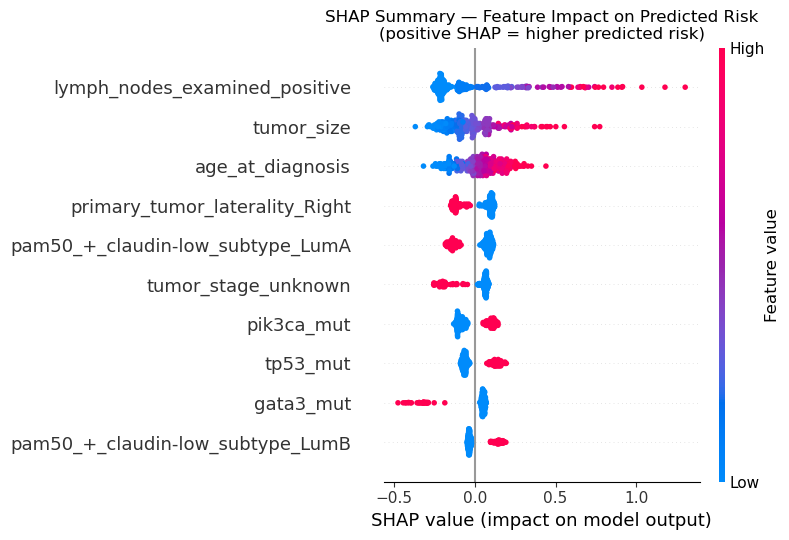

/var/folders/lg/ycvb06q90x9cty7h1176t0200000gn/T/ipykernel_83463/1040468265.py:80: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


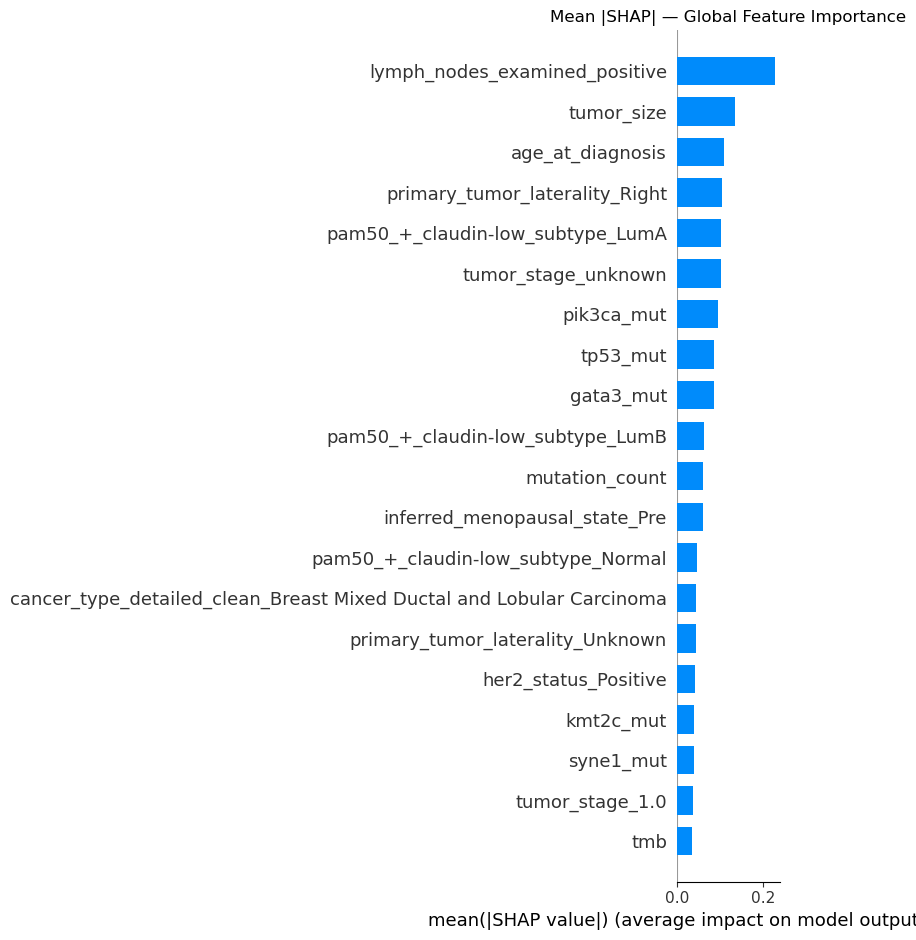


Top 10 most important features:
                         feature  importance     type
   lymph_nodes_examined_positive    0.228439 clinical
                      tumor_size    0.134866 clinical
                age_at_diagnosis    0.110528 clinical
  primary_tumor_laterality_Right    0.104565 clinical
pam50_+_claudin-low_subtype_LumA    0.102522 clinical
             tumor_stage_unknown    0.102096 clinical
                      pik3ca_mut    0.095219 mutation
                        tp53_mut    0.086851 mutation
                       gata3_mut    0.085434 mutation
pam50_+_claudin-low_subtype_LumB    0.063407 clinical

Total importance by modality:
type
clinical    1.355576
mutation    0.674211
Name: importance, dtype: float64


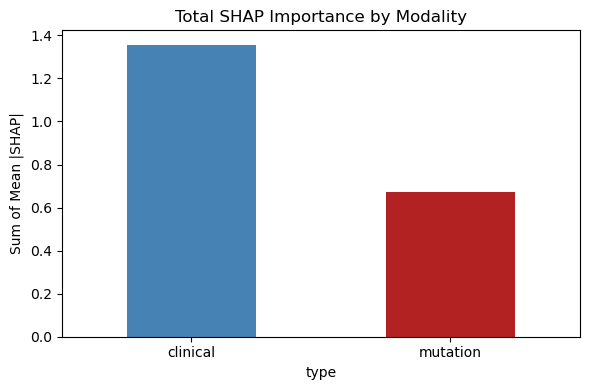


Computing SHAP values for expression features...

Top 20 most important expression features:
    gene  importance
   smad6    0.012828
   apaf1    0.012684
  stat5a    0.012608
   vegfa    0.012466
    bcl2    0.012091
     bmf    0.011807
     fn1    0.011495
   aurka    0.011063
    cdk2    0.010606
   mmp11    0.010584
     src    0.010302
serpini1    0.010259
  stat5b    0.010234
   pdgfb    0.010069
    jag2    0.009829
     st7    0.009717
   maml1    0.009605
    hes4    0.009398
    hes6    0.009292
   rad51    0.009122


/var/folders/lg/ycvb06q90x9cty7h1176t0200000gn/T/ipykernel_83463/1040468265.py:191: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


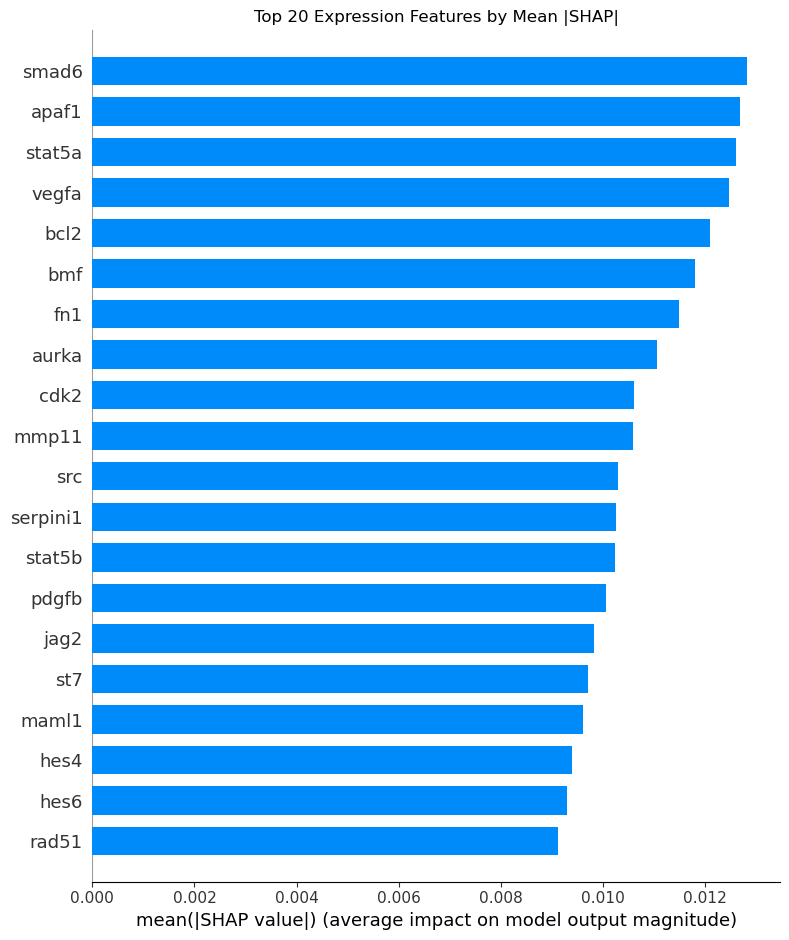

/var/folders/lg/ycvb06q90x9cty7h1176t0200000gn/T/ipykernel_83463/1040468265.py:206: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


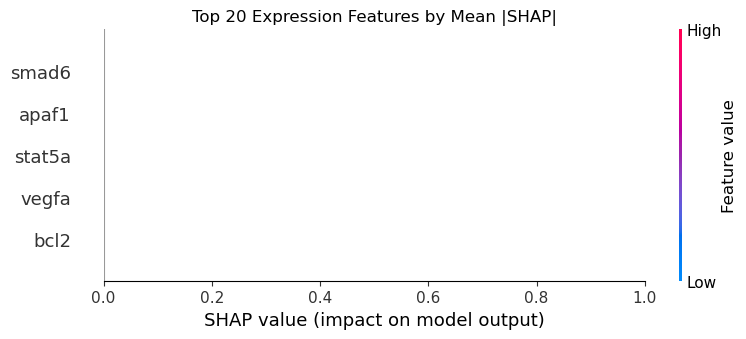


SHAP analysis complete. Files saved:
  shap_summary.png
  shap_bar.png
  shap_modality.png
  shap_dependence.png
  shap_expression_bar.png
  shap_clinical_values.npy
  shap_expression_values.npy
  feature_importance.csv
  gene_importance.csv


In [182]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

set_seed(42)
model_surv_ae.eval()

# ── Wrapper: fix expression input, vary clinical+mutation ─────────
# SHAP varies one modality at a time — we fix expression to the
# mean so SHAP values reflect clinical/mutation feature importance

class ClinicalMutWrapper(nn.Module):
    """Wraps model to accept only clinical+mutation input.
    Expression is fixed to training mean — isolates clinical signal."""
    def __init__(self, model, fixed_expr):
        super().__init__()
        self.model      = model
        self.fixed_expr = fixed_expr

    def forward(self, x_clin):
        expr = self.fixed_expr.expand(x_clin.shape[0], -1)
        return self.model(x_clin, expr).unsqueeze(1)


mean_expr    = expr_train_tensor.mean(dim=0, keepdim=True)
clin_wrapper = ClinicalMutWrapper(model_surv_ae, mean_expr)
clin_wrapper.eval()

# ── Background dataset ────────────────────────────────────────────
# Use k-means summary of training data (faster than full dataset)
# 100 background samples is standard for DeepExplainer
background = X_train_tensor[:100]

#background = X_train_tensor

# ── SHAP explainer ────────────────────────────────────────────────
print("Building SHAP explainer...")
explainer = shap.DeepExplainer(clin_wrapper, background)

# Explain validation set (use all val patients for stable estimates)
print("Computing SHAP values for validation set...")
#shap_values = explainer.shap_values(X_val_tensor)
shap_values = explainer.shap_values(X_test_tensor)

# shap_values shape: (n_patients, n_features, 1) — squeeze last dim
if isinstance(shap_values, list):
    shap_vals = shap_values[0]
else:
    shap_vals = shap_values

if shap_vals.ndim == 3:
    shap_vals = shap_vals[:, :, 0]

print(f"SHAP values shape: {shap_vals.shape}")
print(f"Features:          {len(full_feature_names)}")


# ── Plot 1: Summary plot (beeswarm) ───────────────────────────────
# Shows distribution of SHAP values for each feature
# Red = high feature value, Blue = low feature value
plt.figure()
shap.summary_plot(
    shap_vals,
    X_test_tensor.numpy(),
    feature_names=full_feature_names,
    max_display=10,
    show=False
)


plt.title("SHAP Summary — Feature Impact on Predicted Risk\n"
          "(positive SHAP = higher predicted risk)")
plt.tight_layout()
#plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Plot 2: Bar plot — mean absolute SHAP (feature importance) ────
plt.figure()
shap.summary_plot(
    shap_vals,
    X_test_tensor.numpy(),
    feature_names=full_feature_names,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("Mean |SHAP| — Global Feature Importance")
plt.tight_layout()
#plt.savefig("shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Plot 3: Clinical vs mutation importance breakdown ─────────────
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
importance_df = pd.DataFrame({
    "feature":    full_feature_names,
    "importance": mean_abs_shap,
    "type":       ["clinical"] * len(clin_feature_names) +
                  ["mutation"] * len(mutation_feature_names)
}).sort_values("importance", ascending=False)

print("\nTop 10 most important features:")
print(importance_df.head(10).to_string(index=False))

# Group importance by modality
modality_importance = importance_df.groupby("type")["importance"].sum()
print(f"\nTotal importance by modality:")
print(modality_importance)

fig, ax = plt.subplots(figsize=(6, 4))
modality_importance.plot(kind="bar", ax=ax, color=["steelblue", "firebrick"])
ax.set_title("Total SHAP Importance by Modality")
ax.set_ylabel("Sum of Mean |SHAP|")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
#plt.savefig("shap_modality.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Plot 4: Top feature dependence plots ─────────────────────────
# Shows how SHAP value changes with feature value for top features
# top_features = importance_df.head(4)["feature"].tolist()
# fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# for ax, feat in zip(axes.flatten(), top_features):
#     feat_idx = full_feature_names.index(feat)
#     shap.dependence_plot(
#         feat_idx,
#         shap_vals,
#         X_val_tensor.numpy(),
#         feature_names=full_feature_names,
#         ax=ax,
#         show=False
#     )
#     ax.set_title(f"SHAP Dependence: {feat}")

# plt.tight_layout()
# #plt.savefig("shap_dependence.png", dpi=150, bbox_inches="tight")
# plt.show()


# ── Plot 5: Expression modality importance ────────────────────────
# Separate SHAP analysis on expression latent dimensions
# Shows which latent dimensions drive predictions

class ExprOnlyWrapper(nn.Module):
    """Wraps model to accept only expression input.
    Clinical fixed to training mean — isolates expression signal."""
    def __init__(self, model, fixed_clin):
        super().__init__()
        self.model      = model
        self.fixed_clin = fixed_clin

    def forward(self, x_expr):
        clin = self.fixed_clin.expand(x_expr.shape[0], -1)
        return self.model(clin, x_expr).unsqueeze(1)


mean_clin     = X_train_tensor.mean(dim=0, keepdim=True)
expr_wrapper  = ExprOnlyWrapper(model_surv_ae, mean_clin)
expr_wrapper.eval()

print("\nComputing SHAP values for expression features...")
expr_background  = expr_train_tensor
expr_explainer   = shap.DeepExplainer(expr_wrapper, expr_background)
expr_shap_values = expr_explainer.shap_values(expr_test_tensor)

if isinstance(expr_shap_values, list):
    expr_shap_vals = expr_shap_values[0]
else:
    expr_shap_vals = expr_shap_values

if expr_shap_vals.ndim == 3:
    expr_shap_vals = expr_shap_vals[:, :, 0]

# Get gene names from expression data
gene_names = list(expression_data.columns)

# Top expression features by mean |SHAP|
expr_importance = pd.DataFrame({
    "gene":       gene_names,
    "importance": np.abs(expr_shap_vals).mean(axis=0)
}).sort_values("importance", ascending=False)

print("\nTop 20 most important expression features:")
print(expr_importance.head(20).to_string(index=False))

# Plot top 20 expression features
plt.figure(figsize=(8, 6))
shap.summary_plot(
    expr_shap_vals,
    expr_val_tensor.numpy(),
    feature_names=gene_names,
    max_display=20,
    plot_type="bar",
    show=False
)
plt.title("Top 20 Expression Features by Mean |SHAP|")
plt.tight_layout()
#plt.savefig("shap_expression_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot top 20 expression features
plt.figure(figsize=(8, 6))
shap.summary_plot(
    expr_shap_vals,
    expr_val_tensor.numpy(),
    feature_names=gene_names,
    max_display=5,
    plot_type="beeswarm",
    show=False
)
plt.title("Top 20 Expression Features by Mean |SHAP|")
plt.tight_layout()
#plt.savefig("shap_expression_bar.png", dpi=150, bbox_inches="tight")
plt.show()
# ── Save SHAP values for further analysis ─────────────────────────
# np.save("shap_clinical_values.npy",   shap_vals)
# np.save("shap_expression_values.npy", expr_shap_vals)

# importance_df.to_csv("feature_importance.csv", index=False)
# expr_importance.to_csv("gene_importance.csv",  index=False)

print("\nSHAP analysis complete. Files saved:")
print("  shap_summary.png")
print("  shap_bar.png")
print("  shap_modality.png")
print("  shap_dependence.png")
print("  shap_expression_bar.png")
print("  shap_clinical_values.npy")
print("  shap_expression_values.npy")
print("  feature_importance.csv")
print("  gene_importance.csv")

# Combined Model Evaluation Figures

## Kaplan Meier Curves

In [143]:
pd.DataFrame(event_all).value_counts()

0
0    1282
1     622
Name: count, dtype: int64

Train+Val+Test size: 1904 patients
Group 0
  n = 65
  events = 4
  event rate = 0.062
  median time = 138.1
Group 1
  n = 65
  events = 13
  event rate = 0.200
  median time = 165.2
Group 2
  n = 64
  events = 19
  event rate = 0.297
  median time = 114.7
Group 3
  n = 65
  events = 32
  event rate = 0.492
  median time = 79.8
Group 4
  n = 65
  events = 38
  event rate = 0.585
  median time = 52.6


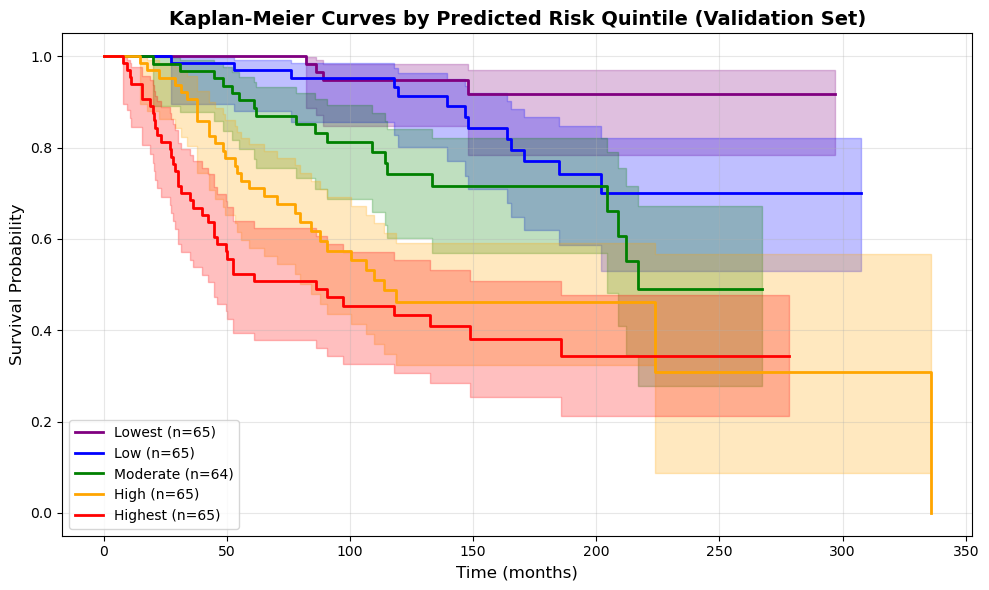

Group 0
  n = 57
  events = 5
  event rate = 0.088
  median time = 141.0
Group 1
  n = 57
  events = 15
  event rate = 0.263
  median time = 140.9
Group 2
  n = 57
  events = 18
  event rate = 0.316
  median time = 111.6
Group 3
  n = 57
  events = 25
  event rate = 0.439
  median time = 84.8
Group 4
  n = 58
  events = 30
  event rate = 0.517
  median time = 72.1


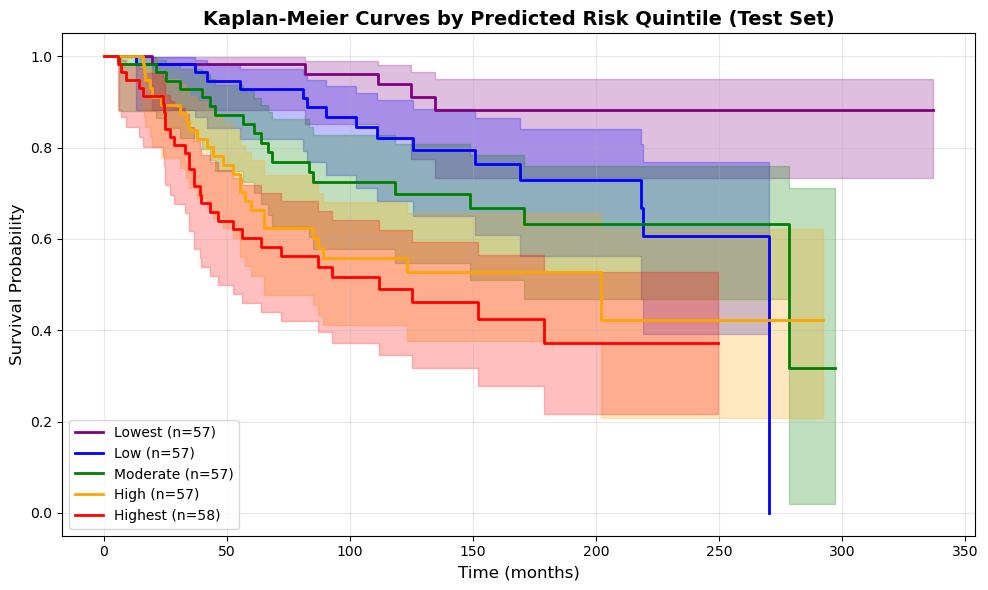

Group 0
  n = 381
  events = 25
  event rate = 0.066
  median time = 147.8
Group 1
  n = 381
  events = 67
  event rate = 0.176
  median time = 144.5
Group 2
  n = 380
  events = 107
  event rate = 0.282
  median time = 129.7
Group 3
  n = 381
  events = 167
  event rate = 0.438
  median time = 88.9
Group 4
  n = 381
  events = 256
  event rate = 0.672
  median time = 49.8


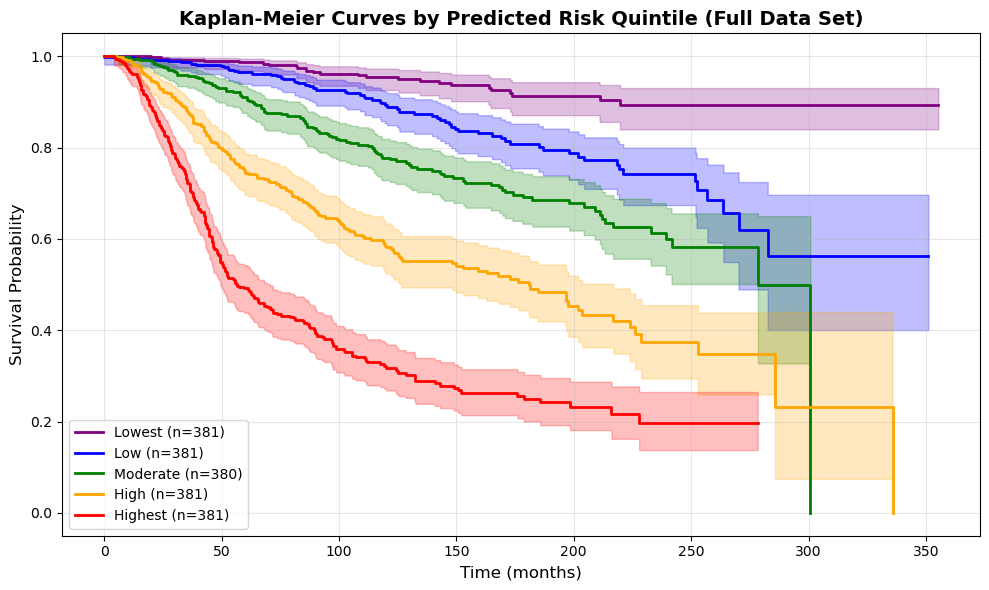

Log-Rank Test (Validation Set)
Test statistic: 73.7479
Degrees of freedom: 4
P-value: 0.000000
Significant (α=0.05): Yes

Log-Rank Test (Test Set)
Test statistic: 611.9869
Degrees of freedom: 4
P-value: 0.000000
Significant (α=0.05): Yes

Risk Score Summary Statistics

Validation Set:
  Mean risk: -0.6178
  Std risk:  0.9323
  Min risk:  -2.4080
  Max risk:  1.6707

Test Set:
  Mean risk: -0.5171
  Std risk:  0.8463
  Min risk:  -3.1553
  Max risk:  1.5970


In [145]:
"""
Kaplan-Meier curves stratified by predicted risk quintiles
for the Survival-Aware Autoencoder model.
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

# Combine all data together for risk prediction

# ── Combine train, val, and test sets ────────────────────────────────────
X_all = np.vstack([X_train_tensor, X_val_tensor, X_test_tensor])
expr_all    = np.vstack([
    expr_train_tensor,
    expr_val_tensor,
    expr_test_tensor
])
time_all    = np.concatenate([time_train, time_val, time_test])
event_all   = np.concatenate([event_train, event_val, event_test])

# Convert to tensors
X_all_tensor    = torch.tensor(X_all,  dtype=torch.float32)
expr_all_tensor = torch.tensor(expr_all,      dtype=torch.float32)
time_all_tensor = torch.tensor(time_all,      dtype=torch.float32)
event_all_tensor = torch.tensor(event_all,    dtype=torch.float32)

surv_all = make_structured_array(event_all, time_all)

print(f"Train+Val+Test size: {X_all_tensor.shape[0]} patients")


# ── Generate risk predictions ──────────────────────────────────
model_surv_ae.eval()
with torch.no_grad():
    val_risk = model_surv_ae(X_val_tensor, expr_val_tensor).numpy()
    test_risk = model_surv_ae(X_test_tensor, expr_test_tensor).numpy()
    all_risk = model_surv_ae(X_all_tensor, expr_all_tensor).numpy()


# ── Helper function to plot KM curves by risk group ──────────
def plot_km_by_risk_group(
    risk_scores, 
    times, 
    events, 
    dataset_name="Validation",
    n_groups=5,
    figsize=(10, 6)
):
    """
    Plot Kaplan-Meier survival curves stratified by risk quintiles.
    
    Args:
        risk_scores: array of predicted risk scores
        times: array of time-to-event
        events: array of event indicators (0/1)
        dataset_name: name for the plot title
        n_groups: number of risk groups (default 5 for quintiles)
        figsize: figure size tuple
    """
    
    # Define percentile cutoffs for n_groups
    percentiles = np.linspace(0, 100, n_groups + 1)[1:-1]
    cutoffs = np.percentile(risk_scores, percentiles)
    
    # Assign risk groups using digitize
    # digitize returns: 0 if x < cutoffs[0], 1 if cutoffs[0] <= x < cutoffs[1], etc.
    risk_groups = np.digitize(risk_scores, cutoffs)
    
    # Labels and colors for quintiles
    if n_groups == 5:
        group_labels = ["Lowest", "Low", "Moderate", "High", "Highest"]
        colors = ["purple", "blue", "green", "orange", "red"]
    elif n_groups == 4:
        group_labels = ["Low", "Moderate", "High", "Very High"]
        colors = ["blue", "green", "orange", "red"]
    elif n_groups == 3:
        group_labels = ["Low", "Moderate", "High"]
        colors = ["blue", "green", "red"]
    else:
        group_labels = [f"Group {i}" for i in range(n_groups)]
        colors = plt.cm.RdYlBu_r(np.linspace(0, 1, n_groups))
    
    # Fit KM curves for each risk group
    kmf = KaplanMeierFitter()
    fig, ax = plt.subplots(figsize=figsize)
    
    # Store results for log-rank test
    group_data = []
    
    for group in range(n_groups):
        mask = risk_groups == group
        n_samples = mask.sum()
        
        if n_samples == 0:
            continue
        
        group_times = times[mask]
        group_events = events[mask]
        
        kmf.fit(
            durations=group_times,
            event_observed=group_events,
            label=f"{group_labels[group]} (n={n_samples})"
        )
        kmf.plot_survival_function(ax=ax, color=colors[group], linewidth=2)
        
        group_data.append({
            'group': group,
            'times': group_times,
            'events': group_events,
            'label': group_labels[group]
        })
    
    for g in range(5):
        mask = risk_groups == g

        print(f"Group {g}")
        print(f"  n = {mask.sum()}")
        print(f"  events = {events[mask].sum()}")
        print(f"  event rate = {events[mask].mean():.3f}")
        print(f"  median time = {np.median(times[mask]):.1f}")

    ax.set_title(
        f"Kaplan-Meier Curves by Predicted Risk Quintile ({dataset_name} Set)",
        fontsize=14,
        fontweight='bold'
    )
    ax.set_xlabel("Time (months)", fontsize=12)
    ax.set_ylabel("Survival Probability", fontsize=12)
    ax.legend(loc='lower left', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    return fig, ax, group_data


# ── Plot validation set ────────────────────────────────────
fig_val, ax_val, val_group_data = plot_km_by_risk_group(
    risk_scores=val_risk,
    times=time_val,
    events=event_val,
    dataset_name="Validation",
    n_groups=5
)
plt.show()


# ── Plot test set ──────────────────────────────────────────
fig_test, ax_test, test_group_data = plot_km_by_risk_group(
    risk_scores=test_risk,
    times=time_test,
    events=event_test,
    dataset_name="Test",
    n_groups=5
)
plt.show()

# ── Plot Full  dataset ──────────────────────────────────────────
fig_test, ax_test, test_group_data = plot_km_by_risk_group(
    risk_scores=all_risk,
    times=time_all,
    events=event_all,
    dataset_name="Full Data",
    n_groups=5
)
plt.show()

# ── Perform log-rank test (validation set) ─────────────────
print("=" * 70)
print("Log-Rank Test (Validation Set)")
print("=" * 70)

# Prepare data for multivariate log-rank test
val_times_list = []
val_events_list = []
val_groups_list = []

for i, group_info in enumerate(val_group_data):
    val_times_list.extend(group_info['times'])
    val_events_list.extend(group_info['events'])
    val_groups_list.extend([group_info['label']] * len(group_info['times']))

val_times_array = np.array(val_times_list)
val_events_array = np.array(val_events_list)
val_groups_array = np.array(val_groups_list)

# Perform test
results = multivariate_logrank_test(
    val_times_array,
    val_groups_array,
    val_events_array
)

print(f"Test statistic: {results.test_statistic:.4f}")
print(f"Degrees of freedom: {results.degrees_of_freedom}")
print(f"P-value: {results.p_value:.6f}")
print(f"Significant (α=0.05): {'Yes' if results.p_value < 0.05 else 'No'}")


# ── Perform log-rank test (test set) ───────────────────────
print("\n" + "=" * 70)
print("Log-Rank Test (Test Set)")
print("=" * 70)

test_times_list = []
test_events_list = []
test_groups_list = []

for i, group_info in enumerate(test_group_data):
    test_times_list.extend(group_info['times'])
    test_events_list.extend(group_info['events'])
    test_groups_list.extend([group_info['label']] * len(group_info['times']))

test_times_array = np.array(test_times_list)
test_events_array = np.array(test_events_list)
test_groups_array = np.array(test_groups_list)

results = multivariate_logrank_test(
    test_times_array,
    test_groups_array,
    test_events_array
)

print(f"Test statistic: {results.test_statistic:.4f}")
print(f"Degrees of freedom: {results.degrees_of_freedom}")
print(f"P-value: {results.p_value:.6f}")
print(f"Significant (α=0.05): {'Yes' if results.p_value < 0.05 else 'No'}")


# ── Summary statistics ─────────────────────────────────────
print("\n" + "=" * 70)
print("Risk Score Summary Statistics")
print("=" * 70)
print(f"\nValidation Set:")
print(f"  Mean risk: {val_risk.mean():.4f}")
print(f"  Std risk:  {val_risk.std():.4f}")
print(f"  Min risk:  {val_risk.min():.4f}")
print(f"  Max risk:  {val_risk.max():.4f}")
print(f"\nTest Set:")
print(f"  Mean risk: {test_risk.mean():.4f}")
print(f"  Std risk:  {test_risk.std():.4f}")
print(f"  Min risk:  {test_risk.min():.4f}")
print(f"  Max risk:  {test_risk.max():.4f}")

Train+Val+Test size: 1904 patients

Validation Set - Risk Group Summary:
High         | n=  65 | events= 32 | event_rate=0.492 | median_time=  79.8
Highest      | n=  65 | events= 38 | event_rate=0.585 | median_time=  52.6
Low          | n=  65 | events= 13 | event_rate=0.200 | median_time= 165.2
Lowest       | n=  65 | events=  4 | event_rate=0.062 | median_time= 138.1
Moderate     | n=  64 | events= 19 | event_rate=0.297 | median_time= 114.7


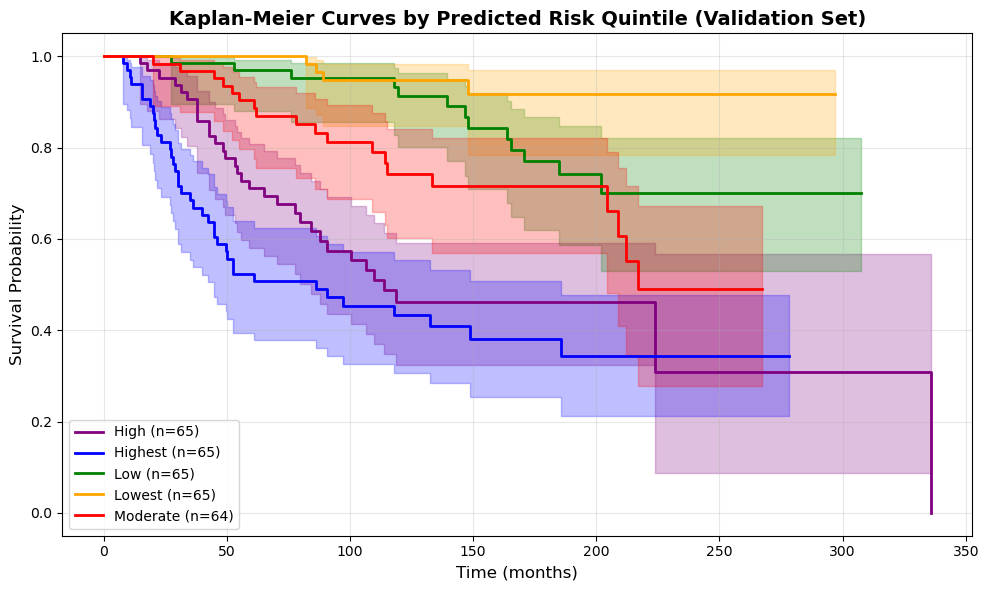


Test Set - Risk Group Summary:
High         | n=  57 | events= 25 | event_rate=0.439 | median_time=  84.8
Highest      | n=  57 | events= 30 | event_rate=0.526 | median_time=  71.8
Low          | n=  57 | events= 14 | event_rate=0.246 | median_time= 140.9
Lowest       | n=  58 | events=  6 | event_rate=0.103 | median_time= 139.8
Moderate     | n=  57 | events= 18 | event_rate=0.316 | median_time= 111.6


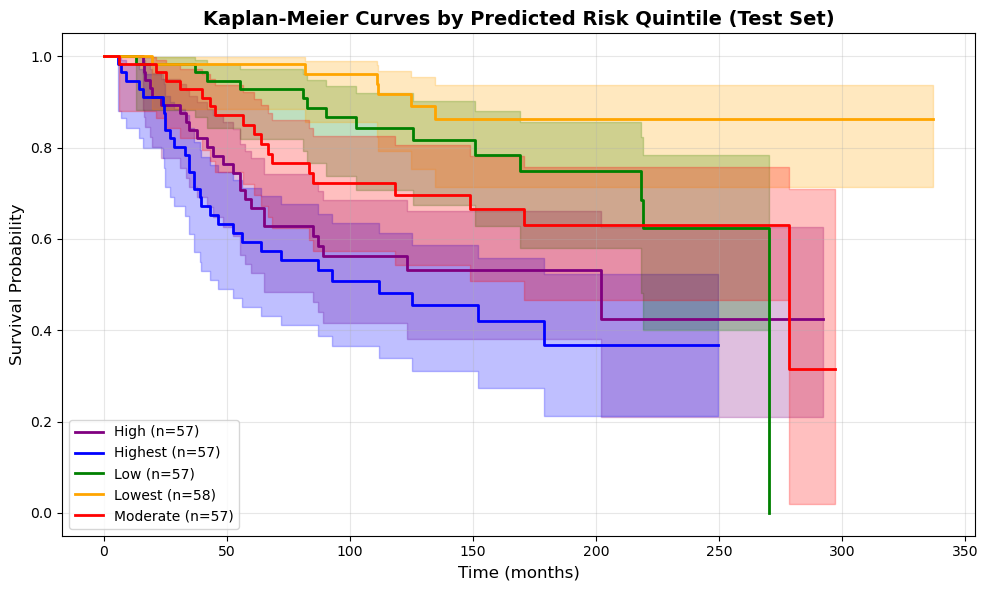


Full Data Set - Risk Group Summary:
High         | n= 381 | events=167 | event_rate=0.438 | median_time=  88.9
Highest      | n= 381 | events=256 | event_rate=0.672 | median_time=  49.8
Low          | n= 381 | events= 67 | event_rate=0.176 | median_time= 144.5
Lowest       | n= 381 | events= 25 | event_rate=0.066 | median_time= 147.8
Moderate     | n= 380 | events=107 | event_rate=0.282 | median_time= 129.7


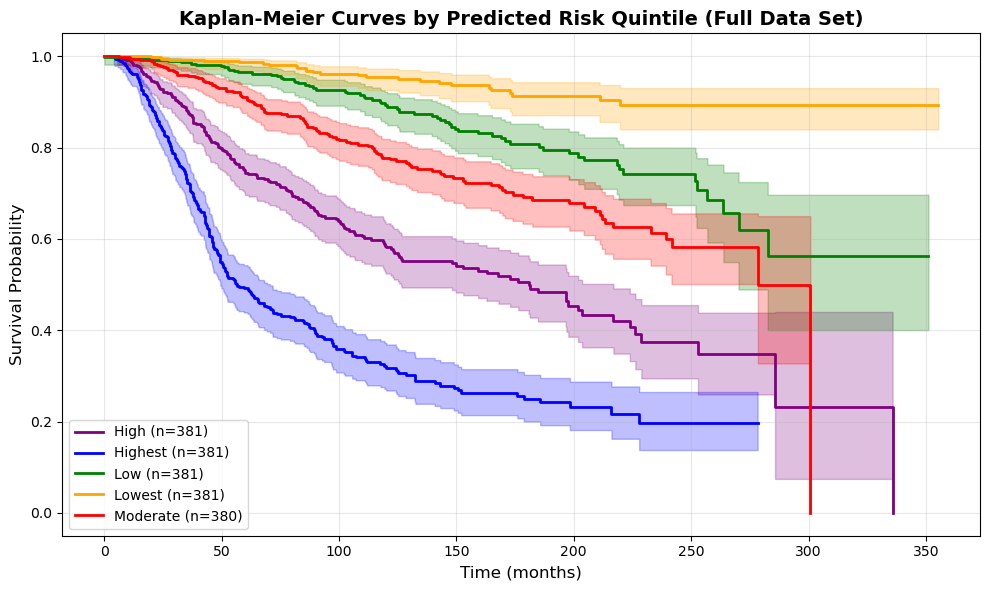


Log-Rank Test (Validation Set)
Test statistic: 73.7479
Degrees of freedom: 4
P-value: 0.000000
Significant (α=0.05): Yes

Log-Rank Test (Test Set)
Test statistic: 39.1486
Degrees of freedom: 4
P-value: 0.000000
Significant (α=0.05): Yes

Log-Rank Test (Full Data Set)
Test statistic: 611.9869
Degrees of freedom: 4
P-value: 0.000000
Significant (α=0.05): Yes

Risk Score Summary Statistics

Validation Set:
  Mean risk: -0.6178
  Std risk:  0.9323
  Min risk:  -2.4080
  Max risk:  1.6707

Test Set:
  Mean risk: -0.5171
  Std risk:  0.8463
  Min risk:  -3.1553
  Max risk:  1.5970

Full Data Set:
  Mean risk: -0.5831
  Std risk:  0.9175
  Min risk:  -3.9011
  Max risk:  1.9142


In [150]:
"""
Kaplan-Meier curves stratified by predicted risk quintiles
for the Survival-Aware Autoencoder model.

FIXED: Uses pd.qcut() for equal-sized quantile-based grouping
(matching lifelines' behavior).
"""

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

# ── Combine all data together for risk prediction ────────────────────────────────────
X_all = np.vstack([X_train_tensor, X_val_tensor, X_test_tensor])
expr_all = np.vstack([
    expr_train_tensor,
    expr_val_tensor,
    expr_test_tensor
])
time_all = np.concatenate([time_train, time_val, time_test])
event_all = np.concatenate([event_train, event_val, event_test])

# Convert to tensors
X_all_tensor = torch.tensor(X_all, dtype=torch.float32)
expr_all_tensor = torch.tensor(expr_all, dtype=torch.float32)

print(f"Train+Val+Test size: {X_all_tensor.shape[0]} patients")

# ── Generate risk predictions ──────────────────────────────────
model_surv_ae.eval()
with torch.no_grad():
    val_risk = model_surv_ae(X_val_tensor, expr_val_tensor).numpy().flatten()
    test_risk = model_surv_ae(X_test_tensor, expr_test_tensor).numpy().flatten()
    all_risk = model_surv_ae(X_all_tensor, expr_all_tensor).numpy().flatten()


# ── Helper function to plot KM curves by risk group (using pd.qcut) ──────────
def plot_km_by_risk_group_qcut(
    risk_scores,
    times,
    events,
    dataset_name="Validation",
    n_groups=5,
    figsize=(10, 6)
):
    """
    Plot Kaplan-Meier survival curves stratified by risk quintiles using pd.qcut().
    
    This creates EQUAL-SIZED groups (quantile-based), matching lifelines behavior.
    
    Args:
        risk_scores: array of predicted risk scores
        times: array of time-to-event
        events: array of event indicators (0/1)
        dataset_name: name for the plot title
        n_groups: number of risk groups (default 5 for quintiles)
        figsize: figure size tuple
    """
    
    # Create DataFrame for easier manipulation
    df = pd.DataFrame({
        'risk': risk_scores,
        'time': times,
        'event': events
    })
    
    # Use pd.qcut for equal-sized quantile-based groups
    if n_groups == 5:
        df['risk_group'] = pd.qcut(
            df['risk'],
            q=5,
            labels=["Lowest", "Low", "Moderate", "High", "Highest"],
            duplicates='drop'  # Handle ties by merging duplicates
        )
        colors = ["purple", "blue", "green", "orange", "red"]
    elif n_groups == 4:
        df['risk_group'] = pd.qcut(
            df['risk'],
            q=4,
            labels=["Low", "Moderate", "High", "Very High"],
            duplicates='drop'
        )
        colors = ["blue", "green", "orange", "red"]
    elif n_groups == 3:
        df['risk_group'] = pd.qcut(
            df['risk'],
            q=3,
            labels=["Low", "Moderate", "High"],
            duplicates='drop'
        )
        colors = ["blue", "green", "red"]
    else:
        df['risk_group'] = pd.qcut(df['risk'], q=n_groups, duplicates='drop')
        colors = plt.cm.RdYlBu_r(np.linspace(0, 1, n_groups))
    
    # Fit KM curves for each risk group
    kmf = KaplanMeierFitter()
    fig, ax = plt.subplots(figsize=figsize)
    
    # Store results for log-rank test
    group_data = []
    
    for i, group in enumerate(sorted(df['risk_group'].unique())):
        mask = df['risk_group'] == group
        n_samples = mask.sum()
        
        if n_samples == 0:
            continue
        
        group_times = df.loc[mask, 'time'].values
        group_events = df.loc[mask, 'event'].values
        
        kmf.fit(
            durations=group_times,
            event_observed=group_events,
            label=f"{group} (n={n_samples})"
        )
        kmf.plot_survival_function(ax=ax, color=colors[i], linewidth=2, ci_show=True)
        
        group_data.append({
            'group': group,
            'times': group_times,
            'events': group_events,
            'label': str(group),
            'n': n_samples,
            'events_count': group_events.sum(),
            'event_rate': group_events.mean()
        })
    
    # Print summary statistics
    print(f"\n{dataset_name} Set - Risk Group Summary:")
    print("=" * 70)
    for g in group_data:
        print(f"{g['label']:12} | n={g['n']:4d} | events={g['events_count']:3d} | "
              f"event_rate={g['event_rate']:.3f} | median_time={np.median(g['times']):6.1f}")
    
    ax.set_title(
        f"Kaplan-Meier Curves by Predicted Risk Quintile ({dataset_name} Set)",
        fontsize=14,
        fontweight='bold'
    )
    ax.set_xlabel("Time (months)", fontsize=12)
    ax.set_ylabel("Survival Probability", fontsize=12)
    ax.legend(loc='lower left', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    return fig, ax, group_data


# ── Plot validation set ────────────────────────────────────
fig_val, ax_val, val_group_data = plot_km_by_risk_group_qcut(
    risk_scores=val_risk,
    times=time_val,
    events=event_val,
    dataset_name="Validation",
    n_groups=5
)
plt.show()

# ── Plot test set ──────────────────────────────────────────
fig_test, ax_test, test_group_data = plot_km_by_risk_group_qcut(
    risk_scores=test_risk,
    times=time_test,
    events=event_test,
    dataset_name="Test",
    n_groups=5
)
plt.show()

# ── Plot Full dataset ──────────────────────────────────────────
fig_all, ax_all, all_group_data = plot_km_by_risk_group_qcut(
    risk_scores=all_risk,
    times=time_all,
    events=event_all,
    dataset_name="Full Data",
    n_groups=5
)
plt.show()


# ── Perform log-rank test (validation set) ─────────────────
print("\n" + "=" * 70)
print("Log-Rank Test (Validation Set)")
print("=" * 70)

# Prepare data for multivariate log-rank test
val_times_list = []
val_events_list = []
val_groups_list = []

for i, group_info in enumerate(val_group_data):
    val_times_list.extend(group_info['times'])
    val_events_list.extend(group_info['events'])
    val_groups_list.extend([group_info['label']] * len(group_info['times']))

val_times_array = np.array(val_times_list)
val_events_array = np.array(val_events_list)
val_groups_array = np.array(val_groups_list)

# Perform test
results = multivariate_logrank_test(
    val_times_array,
    val_groups_array,
    val_events_array
)

print(f"Test statistic: {results.test_statistic:.4f}")
print(f"Degrees of freedom: {results.degrees_of_freedom}")
print(f"P-value: {results.p_value:.6f}")
print(f"Significant (α=0.05): {'Yes' if results.p_value < 0.05 else 'No'}")


# ── Perform log-rank test (test set) ───────────────────────
print("\n" + "=" * 70)
print("Log-Rank Test (Test Set)")
print("=" * 70)

test_times_list = []
test_events_list = []
test_groups_list = []

for i, group_info in enumerate(test_group_data):
    test_times_list.extend(group_info['times'])
    test_events_list.extend(group_info['events'])
    test_groups_list.extend([group_info['label']] * len(group_info['times']))

test_times_array = np.array(test_times_list)
test_events_array = np.array(test_events_list)
test_groups_array = np.array(test_groups_list)

results = multivariate_logrank_test(
    test_times_array,
    test_groups_array,
    test_events_array
)

print(f"Test statistic: {results.test_statistic:.4f}")
print(f"Degrees of freedom: {results.degrees_of_freedom}")
print(f"P-value: {results.p_value:.6f}")
print(f"Significant (α=0.05): {'Yes' if results.p_value < 0.05 else 'No'}")


# ── Perform log-rank test (full dataset) ───────────────────
print("\n" + "=" * 70)
print("Log-Rank Test (Full Data Set)")
print("=" * 70)

all_times_list = []
all_events_list = []
all_groups_list = []

for i, group_info in enumerate(all_group_data):
    all_times_list.extend(group_info['times'])
    all_events_list.extend(group_info['events'])
    all_groups_list.extend([group_info['label']] * len(group_info['times']))

all_times_array = np.array(all_times_list)
all_events_array = np.array(all_events_list)
all_groups_array = np.array(all_groups_list)

results = multivariate_logrank_test(
    all_times_array,
    all_groups_array,
    all_events_array
)

print(f"Test statistic: {results.test_statistic:.4f}")
print(f"Degrees of freedom: {results.degrees_of_freedom}")
print(f"P-value: {results.p_value:.6f}")
print(f"Significant (α=0.05): {'Yes' if results.p_value < 0.05 else 'No'}")


# ── Summary statistics ─────────────────────────────────────
print("\n" + "=" * 70)
print("Risk Score Summary Statistics")
print("=" * 70)
print(f"\nValidation Set:")
print(f"  Mean risk: {val_risk.mean():.4f}")
print(f"  Std risk:  {val_risk.std():.4f}")
print(f"  Min risk:  {val_risk.min():.4f}")
print(f"  Max risk:  {val_risk.max():.4f}")
print(f"\nTest Set:")
print(f"  Mean risk: {test_risk.mean():.4f}")
print(f"  Std risk:  {test_risk.std():.4f}")
print(f"  Min risk:  {test_risk.min():.4f}")
print(f"  Max risk:  {test_risk.max():.4f}")
print(f"\nFull Data Set:")
print(f"  Mean risk: {all_risk.mean():.4f}")
print(f"  Std risk:  {all_risk.std():.4f}")
print(f"  Min risk:  {all_risk.min():.4f}")
print(f"  Max risk:  {all_risk.max():.4f}")

## K-M curves of lowest and highest risk patients


Validation Set: Extreme Risk Patients

Lowest Risk Patient:
  Index: 37
  Risk Score: -2.407997
  Follow-up Time: 236.9 months
  Event: No (censored)

Highest Risk Patient:
  Index: 133
  Risk Score: 1.670698
  Follow-up Time: 28.9 months
  Event: Yes (died)

Risk Ratio (Highest/Lowest): -0.69x

Test Set: Extreme Risk Patients

Lowest Risk Patient:
  Index: 260
  Risk Score: -3.155284
  Follow-up Time: 62.9 months
  Event: No (censored)

Highest Risk Patient:
  Index: 66
  Risk Score: 1.597043
  Follow-up Time: 178.7 months
  Event: Yes (died)

Risk Ratio (Highest/Lowest): -0.51x


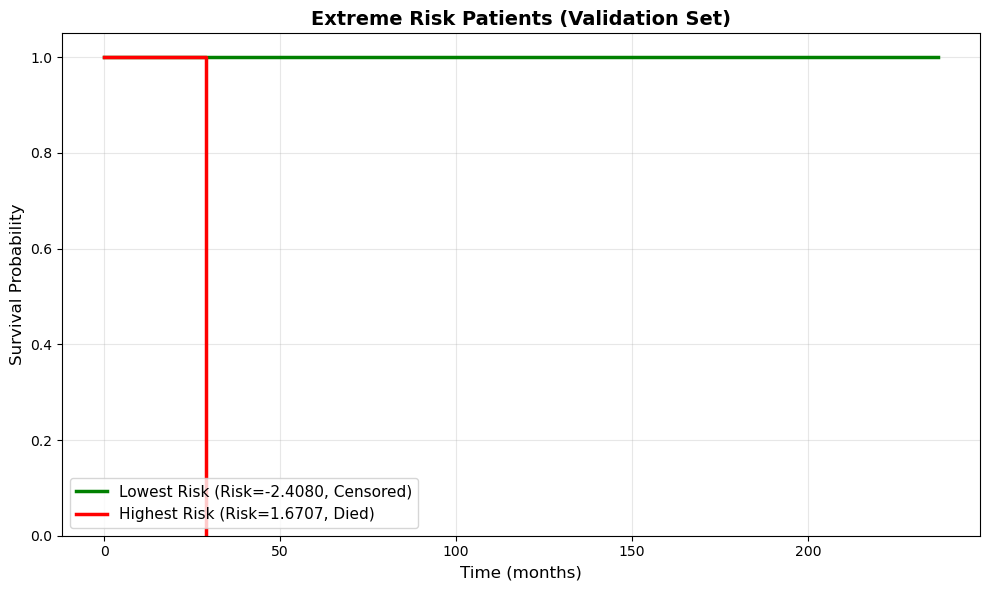

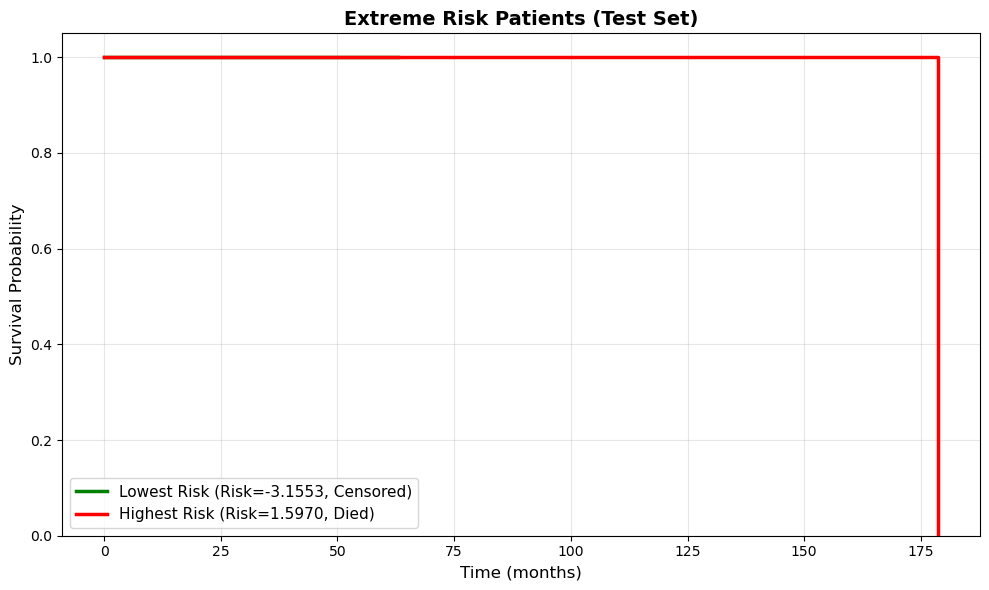

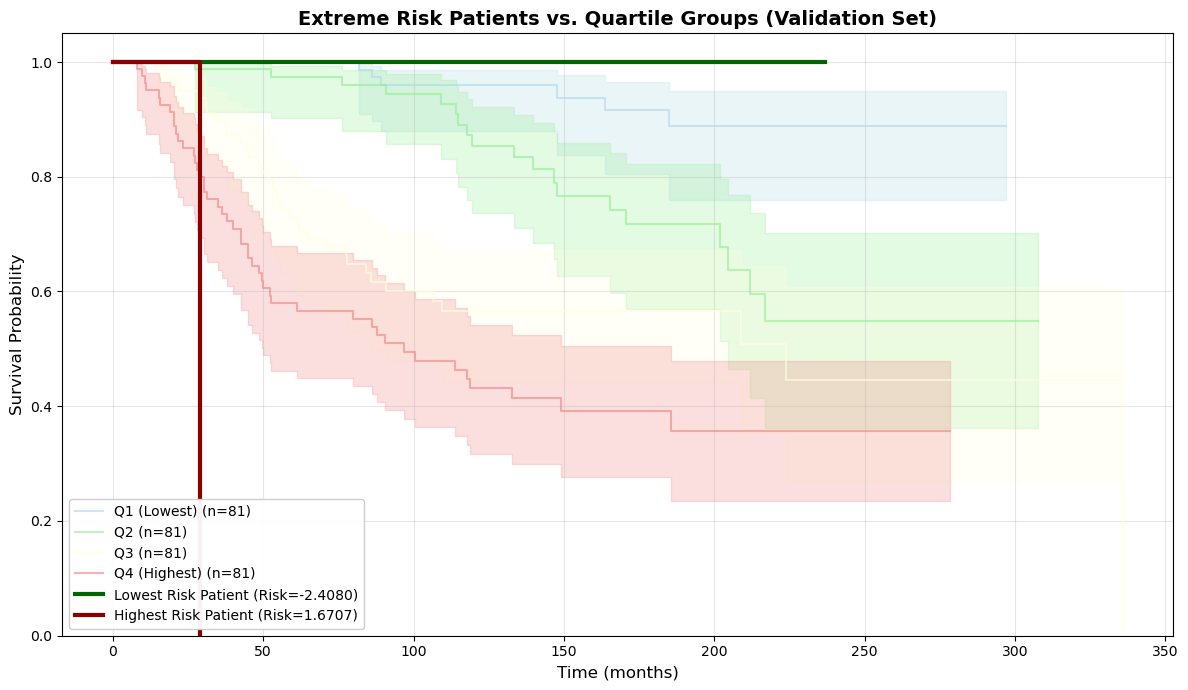

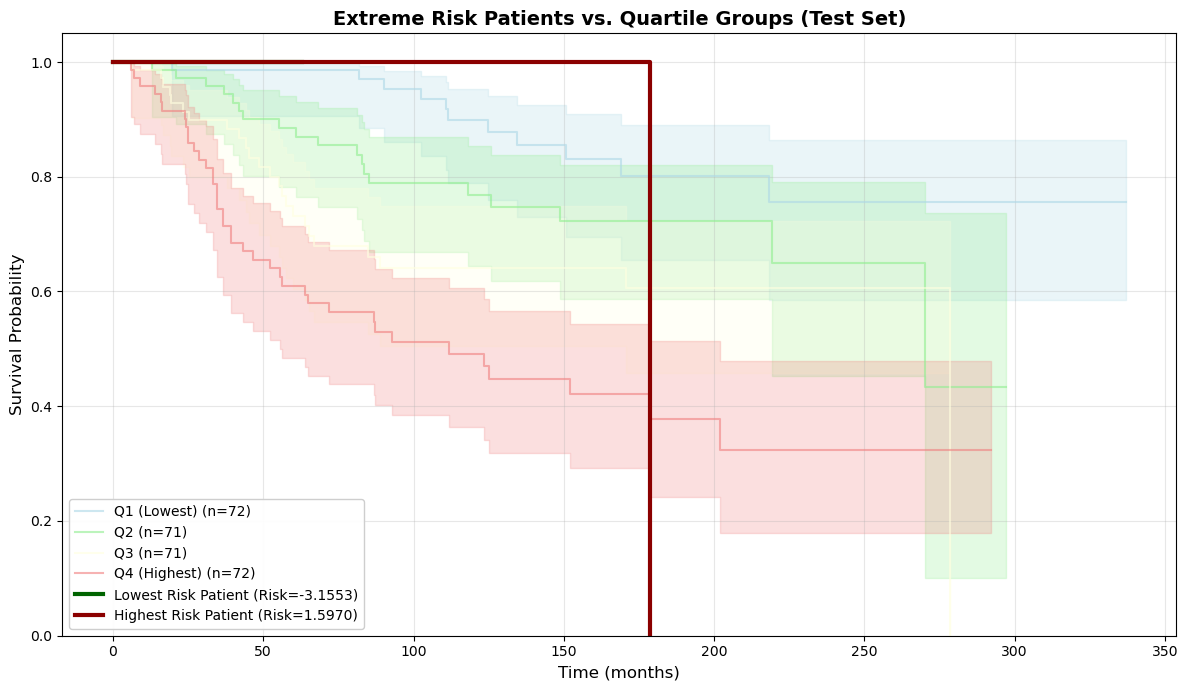

In [146]:
"""
Plot Kaplan-Meier survival curves for the single lowest and highest risk patients.
This shows the extreme predictions of your model.
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# ── Generate risk predictions ──────────────────────────────────
model_surv_ae.eval()
with torch.no_grad():
    val_risk = model_surv_ae(X_val_tensor, expr_val_tensor).numpy()
    test_risk = model_surv_ae(X_test_tensor, expr_test_tensor).numpy()


# ── Find lowest and highest risk patients ──────────────────────
def find_extreme_risk_patients(risk_scores, times, events, dataset_name="Validation"):
    """
    Find the individual patients with lowest and highest risk scores.
    
    Args:
        risk_scores: array of predicted risk scores
        times: array of time-to-event
        events: array of event indicators (0/1)
        dataset_name: name of dataset
    
    Returns:
        Dictionary with info about lowest and highest risk patients
    """
    
    lowest_idx = np.argmin(risk_scores)
    highest_idx = np.argmax(risk_scores)
    
    lowest_risk = risk_scores[lowest_idx]
    highest_risk = risk_scores[highest_idx]
    
    lowest_time = times[lowest_idx]
    highest_time = times[highest_idx]
    
    lowest_event = events[lowest_idx]
    highest_event = events[highest_idx]
    
    print(f"\n{'='*70}")
    print(f"{dataset_name} Set: Extreme Risk Patients")
    print(f"{'='*70}")
    print(f"\nLowest Risk Patient:")
    print(f"  Index: {lowest_idx}")
    print(f"  Risk Score: {lowest_risk:.6f}")
    print(f"  Follow-up Time: {lowest_time:.1f} months")
    print(f"  Event: {'Yes (died)' if lowest_event == 1 else 'No (censored)'}")
    
    print(f"\nHighest Risk Patient:")
    print(f"  Index: {highest_idx}")
    print(f"  Risk Score: {highest_risk:.6f}")
    print(f"  Follow-up Time: {highest_time:.1f} months")
    print(f"  Event: {'Yes (died)' if highest_event == 1 else 'No (censored)'}")
    
    print(f"\nRisk Ratio (Highest/Lowest): {highest_risk / lowest_risk:.2f}x")
    
    return {
        'lowest': {
            'idx': lowest_idx,
            'risk': lowest_risk,
            'time': lowest_time,
            'event': lowest_event
        },
        'highest': {
            'idx': highest_idx,
            'risk': highest_risk,
            'time': highest_time,
            'event': highest_event
        }
    }


# ── Find extreme patients in each dataset ──────────────────────
val_extreme = find_extreme_risk_patients(
    val_risk, time_val, event_val, dataset_name="Validation"
)

test_extreme = find_extreme_risk_patients(
    test_risk, time_test, event_test, dataset_name="Test"
)


# ── Plot single patient survival curves ────────────────────────
def plot_single_patient_curves(extreme_info, dataset_name, times, events):
    """
    Plot KM curves for lowest and highest risk patients as single-patient "cohorts".
    
    Note: A KM curve for a single patient is step-wise: 100% survival until event/censoring.
    """
    
    kmf = KaplanMeierFitter()
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Lowest risk patient
    lowest_idx = extreme_info['lowest']['idx']
    lowest_risk = extreme_info['lowest']['risk']
    lowest_time = extreme_info['lowest']['time']
    lowest_event = extreme_info['lowest']['event']
    event_label = "Died" if lowest_event == 1 else "Censored"
    
    kmf.fit(
        durations=[lowest_time],
        event_observed=[lowest_event],
        label=f"Lowest Risk (Risk={lowest_risk:.4f}, {event_label})"
    )
    kmf.plot_survival_function(ax=ax, color='green', linewidth=2.5, ci_show=False)
    
    # Highest risk patient
    highest_idx = extreme_info['highest']['idx']
    highest_risk = extreme_info['highest']['risk']
    highest_time = extreme_info['highest']['time']
    highest_event = extreme_info['highest']['event']
    event_label = "Died" if highest_event == 1 else "Censored"
    
    kmf.fit(
        durations=[highest_time],
        event_observed=[highest_event],
        label=f"Highest Risk (Risk={highest_risk:.4f}, {event_label})"
    )
    kmf.plot_survival_function(ax=ax, color='red', linewidth=2.5, ci_show=False)
    
    ax.set_title(
        f"Extreme Risk Patients ({dataset_name} Set)",
        fontsize=14,
        fontweight='bold'
    )
    ax.set_xlabel("Time (months)", fontsize=12)
    ax.set_ylabel("Survival Probability", fontsize=12)
    ax.legend(loc='lower left', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])
    plt.tight_layout()
    
    return fig, ax


# Plot validation set extreme patients
fig_val, ax_val = plot_single_patient_curves(
    val_extreme, "Validation", time_val, event_val
)
plt.show()

# Plot test set extreme patients
fig_test, ax_test = plot_single_patient_curves(
    test_extreme, "Test", time_test, event_test
)
plt.show()


# ── Alternative: Plot extreme patients with quartile comparisons ─
def plot_extreme_vs_quartiles(risk_scores, times, events, dataset_name="Validation"):
    """
    Plot lowest and highest individual patients alongside risk quartile groups
    for context.
    """
    
    lowest_idx = np.argmin(risk_scores)
    highest_idx = np.argmax(risk_scores)
    
    lowest_risk = risk_scores[lowest_idx]
    highest_risk = risk_scores[highest_idx]
    
    # Create quartile groups for context
    quartiles = np.percentile(risk_scores, [25, 50, 75])
    risk_groups = np.digitize(risk_scores, quartiles)
    
    kmf = KaplanMeierFitter()
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Plot quartile groups (lighter colors, thinner lines)
    group_labels = ["Q1 (Lowest)", "Q2", "Q3", "Q4 (Highest)"]
    colors_quartiles = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral']
    
    for group in range(4):
        mask = risk_groups == group
        n_samples = mask.sum()
        
        if n_samples > 1:  # Need at least 2 for KM curve
            kmf.fit(
                durations=times[mask],
                event_observed=events[mask],
                label=f"{group_labels[group]} (n={n_samples})"
            )
            kmf.plot_survival_function(
                ax=ax, 
                color=colors_quartiles[group],
                linewidth=1.5,
                alpha=0.6
            )
    
    # Overlay individual extreme patients (bold lines)
    kmf.fit(
        durations=[times[lowest_idx]],
        event_observed=[events[lowest_idx]],
        label=f"Lowest Risk Patient (Risk={lowest_risk:.4f})"
    )
    kmf.plot_survival_function(ax=ax, color='darkgreen', linewidth=3, ci_show=False)
    
    kmf.fit(
        durations=[times[highest_idx]],
        event_observed=[events[highest_idx]],
        label=f"Highest Risk Patient (Risk={highest_risk:.4f})"
    )
    kmf.plot_survival_function(ax=ax, color='darkred', linewidth=3, ci_show=False)
    
    ax.set_title(
        f"Extreme Risk Patients vs. Quartile Groups ({dataset_name} Set)",
        fontsize=14,
        fontweight='bold'
    )
    ax.set_xlabel("Time (months)", fontsize=12)
    ax.set_ylabel("Survival Probability", fontsize=12)
    ax.legend(loc='lower left', fontsize=10, framealpha=0.95)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])
    plt.tight_layout()
    
    return fig, ax


# Plot with quartile context
fig_val_ctx, ax_val_ctx = plot_extreme_vs_quartiles(
    val_risk, time_val, event_val, dataset_name="Validation"
)
plt.show()

fig_test_ctx, ax_test_ctx = plot_extreme_vs_quartiles(
    test_risk, time_test, event_test, dataset_name="Test"
)
plt.show()

Baseline survival estimated from validation set
  Timepoints: 104
  Time range: 7.9 to 335.7 months

Validation Set: Predicted Survival Curves

Lowest Risk Patient:
  Risk Score: -2.407997
  Predicted 1-year survival: 0.9985
  Predicted 5-year survival: 0.9755

Highest Risk Patient:
  Risk Score: 1.670698
  Predicted 1-year survival: 0.9164
  Predicted 5-year survival: 0.2310

Risk Ratio (Highest/Lowest): -0.69x


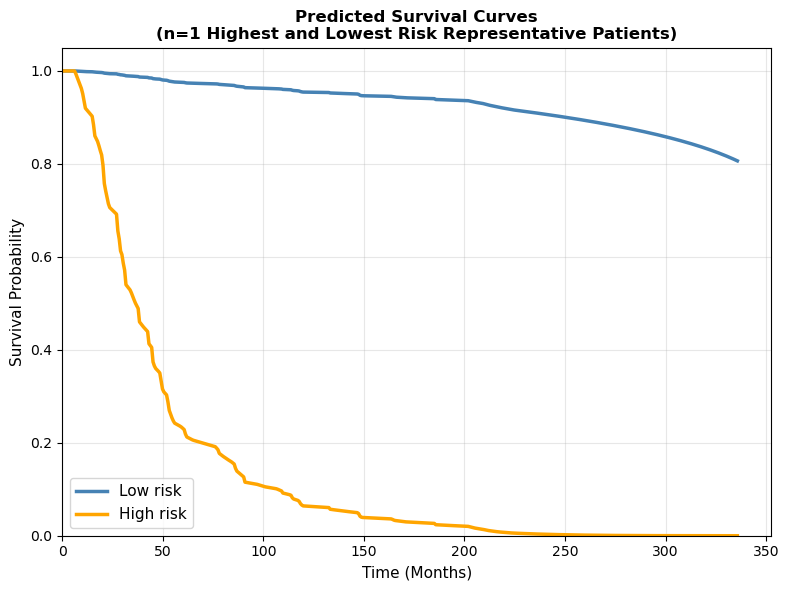


Test Set: Predicted Survival Curves

Lowest Risk Patient:
  Risk Score: -3.155284
  Predicted 1-year survival: 0.9991
  Predicted 5-year survival: 0.9880

Highest Risk Patient:
  Risk Score: 1.597043
  Predicted 1-year survival: 0.9038
  Predicted 5-year survival: 0.2474

Risk Ratio (Highest/Lowest): -0.51x


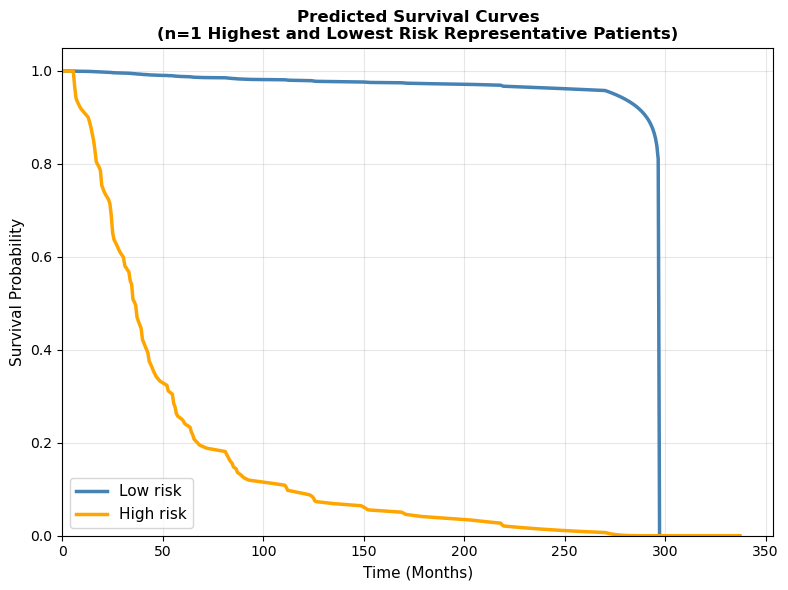

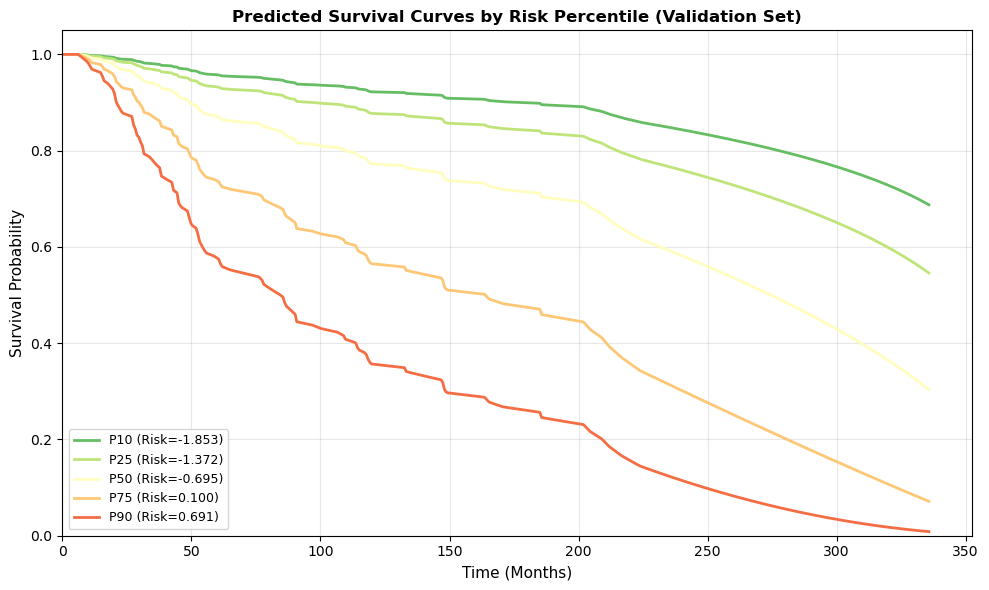

In [147]:
"""
Plot predicted survival curves for the lowest and highest risk patients
using a PyTorch-based survival model with Cox proportional hazards framework.

This mimics lifelines' predict_survival_function() for neural network models.
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


# ── Generate risk predictions ──────────────────────────────────
model_surv_ae.eval()
with torch.no_grad():
    val_risk = model_surv_ae(X_val_tensor, expr_val_tensor).numpy().flatten()
    test_risk = model_surv_ae(X_test_tensor, expr_test_tensor).numpy().flatten()


# ── Helper: Estimate baseline survival from training data ────────
def estimate_baseline_survival(risk_scores, times, events):
    """
    Estimate the baseline survival function S_0(t) using the Breslow estimator.
    
    This is the survival function at the mean risk (risk_score = 0).
    For a Cox model: S(t | x) = S_0(t) ^ exp(risk_score)
    
    Args:
        risk_scores: predicted risk scores from the model
        times: event times
        events: event indicators (1 = event, 0 = censored)
    
    Returns:
        times_unique: sorted unique event times
        baseline_surv: baseline survival at each time
    """
    
    # Sort by time
    sort_idx = np.argsort(times)
    times_sorted = times[sort_idx]
    events_sorted = events[sort_idx]
    risk_sorted = risk_scores[sort_idx]
    
    # Breslow estimator for baseline cumulative hazard
    unique_times = np.sort(np.unique(times_sorted[events_sorted == 1]))
    
    baseline_surv = []
    cumulative_hazard = 0
    
    for t in unique_times:
        # Number of events at time t
        n_events_at_t = np.sum((times_sorted == t) & (events_sorted == 1))
        
        # Risk set: all patients still alive at time t
        at_risk = times_sorted >= t
        exp_risk_sum = np.sum(np.exp(risk_sorted[at_risk]))
        
        # Update cumulative hazard (Breslow)
        cumulative_hazard += n_events_at_t / exp_risk_sum
        
        # Baseline survival: S_0(t) = exp(-cumulative_hazard)
        baseline_surv.append(np.exp(-cumulative_hazard))
    
    return unique_times, np.array(baseline_surv)


# ── Estimate baseline survival from training data ──────────────
baseline_times, baseline_surv = estimate_baseline_survival(
    risk_scores=val_risk,
    times=time_val,
    events=event_val
)

print("Baseline survival estimated from validation set")
print(f"  Timepoints: {len(baseline_times)}")
print(f"  Time range: {baseline_times[0]:.1f} to {baseline_times[-1]:.1f} months")


# ── Function to predict individual survival curve ───────────────
def predict_survival_curve(risk_score, baseline_times, baseline_surv, 
                          time_points=None):
    """
    Predict survival curve for an individual given their risk score.
    
    Using Cox model: S(t | x) = S_0(t) ^ exp(risk_score)
    
    Args:
        risk_score: predicted hazard/risk score for the patient
        baseline_times: timepoints of baseline survival
        baseline_surv: baseline survival values
        time_points: specific timepoints to predict at (default: use baseline_times)
    
    Returns:
        times: timepoints
        survival_probs: predicted survival probabilities
    """
    
    if time_points is None:
        times = baseline_times
    else:
        times = time_points
    
    # Interpolate baseline survival to all timepoints
    baseline_interp = interp1d(
        baseline_times, baseline_surv,
        kind='linear', bounds_error=False,
        fill_value='extrapolate'
    )
    
    baseline_at_t = baseline_interp(times)
    
    # Clip to valid range [0, 1]
    baseline_at_t = np.clip(baseline_at_t, 0, 1)
    
    # Cox model: S(t | x) = S_0(t) ^ exp(risk_score)
    survival_probs = baseline_at_t ** np.exp(risk_score)
    
    return times, survival_probs


# ── Find and plot lowest/highest risk patients ──────────────────
def plot_predicted_survival_curves(risk_scores, times, events, baseline_times, 
                                   baseline_surv, dataset_name="Validation",
                                   figsize=(8, 6)):
    """
    Plot predicted survival curves for lowest and highest risk patients.
    """
    
    lowest_idx = np.argmin(risk_scores)
    highest_idx = np.argmax(risk_scores)
    
    lowest_risk = risk_scores[lowest_idx]
    highest_risk = risk_scores[highest_idx]
    
    # Create dense timepoint grid for smooth curves
    max_time = times.max()
    time_grid = np.linspace(0, max_time, 500)
    
    # Predict survival curves
    times_low, surv_low = predict_survival_curve(
        lowest_risk, baseline_times, baseline_surv, time_points=time_grid
    )
    
    times_high, surv_high = predict_survival_curve(
        highest_risk, baseline_times, baseline_surv, time_points=time_grid
    )
    
    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    
    ax.plot(times_low, surv_low, label="Low risk", 
            color='steelblue', linewidth=2.5)
    ax.plot(times_high, surv_high, label="High risk", 
            color='orange', linewidth=2.5)
    
    ax.set_xlabel("Time (Months)", fontsize=11)
    ax.set_ylabel("Survival Probability", fontsize=11)
    ax.set_title(f"Predicted Survival Curves\n(n=1 Highest and Lowest Risk Representative Patients)",
                 fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1.05])
    ax.set_xlim([0, max_time * 1.05])
    ax.legend(fontsize=11, loc='lower left')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Print info
    print(f"\n{'='*70}")
    print(f"{dataset_name} Set: Predicted Survival Curves")
    print(f"{'='*70}")
    print(f"\nLowest Risk Patient:")
    print(f"  Risk Score: {lowest_risk:.6f}")
    print(f"  Predicted 1-year survival: {surv_low[np.argmin(np.abs(times_low - 12))]:.4f}")
    print(f"  Predicted 5-year survival: {surv_low[np.argmin(np.abs(times_low - 60))]:.4f}")
    
    print(f"\nHighest Risk Patient:")
    print(f"  Risk Score: {highest_risk:.6f}")
    print(f"  Predicted 1-year survival: {surv_high[np.argmin(np.abs(times_high - 12))]:.4f}")
    print(f"  Predicted 5-year survival: {surv_high[np.argmin(np.abs(times_high - 60))]:.4f}")
    
    print(f"\nRisk Ratio (Highest/Lowest): {highest_risk / lowest_risk:.2f}x")
    
    return fig, ax


# Plot validation set
fig_val, ax_val = plot_predicted_survival_curves(
    val_risk, time_val, event_val,
    baseline_times, baseline_surv,
    dataset_name="Validation"
)
plt.show()


# ── Alternative: Use test set baseline ────────────────────────
baseline_times_test, baseline_surv_test = estimate_baseline_survival(
    risk_scores=test_risk,
    times=time_test,
    events=event_test
)

# Plot test set
fig_test, ax_test = plot_predicted_survival_curves(
    test_risk, time_test, event_test,
    baseline_times_test, baseline_surv_test,
    dataset_name="Test"
)
plt.show()


# ── Extended: Plot multiple risk percentiles ─────────────────────
def plot_predicted_curves_by_risk_percentile(risk_scores, times, events, 
                                             baseline_times, baseline_surv,
                                             percentiles=[10, 25, 50, 75, 90],
                                             dataset_name="Validation",
                                             figsize=(10, 6)):
    """
    Plot predicted survival curves for patients at different risk percentiles.
    """
    
    max_time = times.max()
    time_grid = np.linspace(0, max_time, 500)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Colormap for percentiles
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(percentiles)))
    
    for perc, color in zip(percentiles, colors):
        risk_score_at_perc = np.percentile(risk_scores, perc)
        
        times_pred, surv_pred = predict_survival_curve(
            risk_score_at_perc, baseline_times, baseline_surv, 
            time_points=time_grid
        )
        
        ax.plot(times_pred, surv_pred, 
                label=f"P{perc} (Risk={risk_score_at_perc:.3f})",
                color=color, linewidth=2.0)
    
    ax.set_xlabel("Time (Months)", fontsize=11)
    ax.set_ylabel("Survival Probability", fontsize=11)
    ax.set_title(f"Predicted Survival Curves by Risk Percentile ({dataset_name} Set)",
                 fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1.05])
    ax.set_xlim([0, max_time * 1.05])
    ax.legend(fontsize=9, loc='lower left')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    return fig, ax


# Plot by risk percentile
fig_perc, ax_perc = plot_predicted_curves_by_risk_percentile(
    val_risk, time_val, event_val,
    baseline_times, baseline_surv,
    percentiles=[10, 25, 50, 75, 90],
    dataset_name="Validation"
)
plt.show()

## C-index over time 

Computing C-index over follow-up time...
  Training: 20 landmarks
  Validation: 17 landmarks
  Test: 20 landmarks

Overall C-index:
  Training: 0.7951
  Validation: 0.7680
  Test: 0.7139


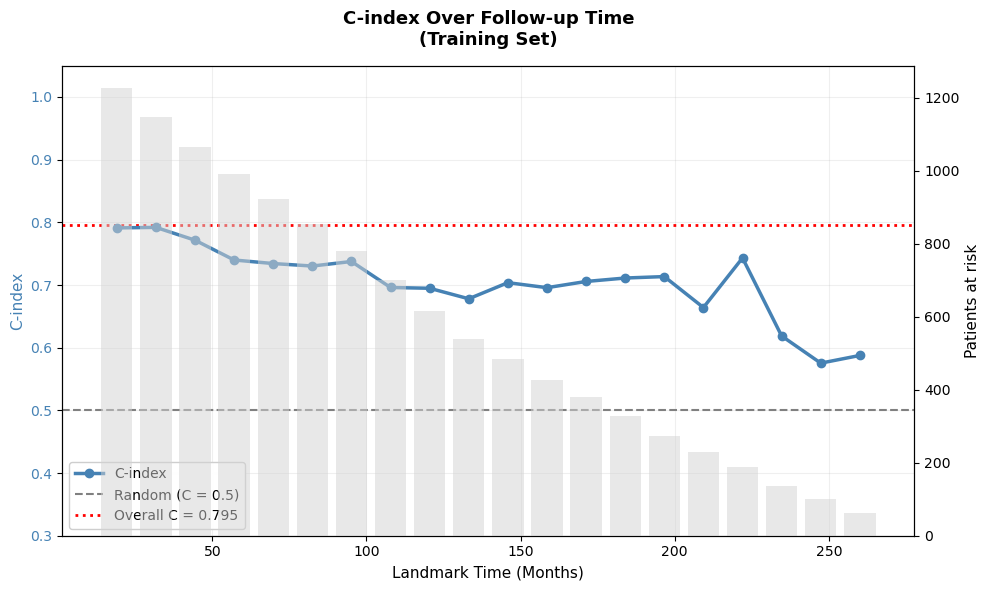

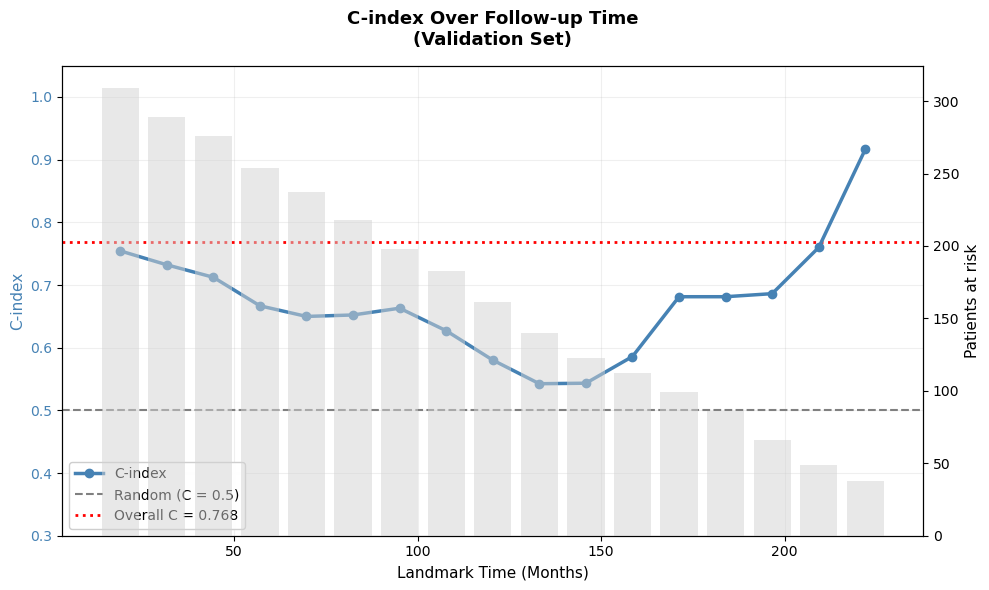

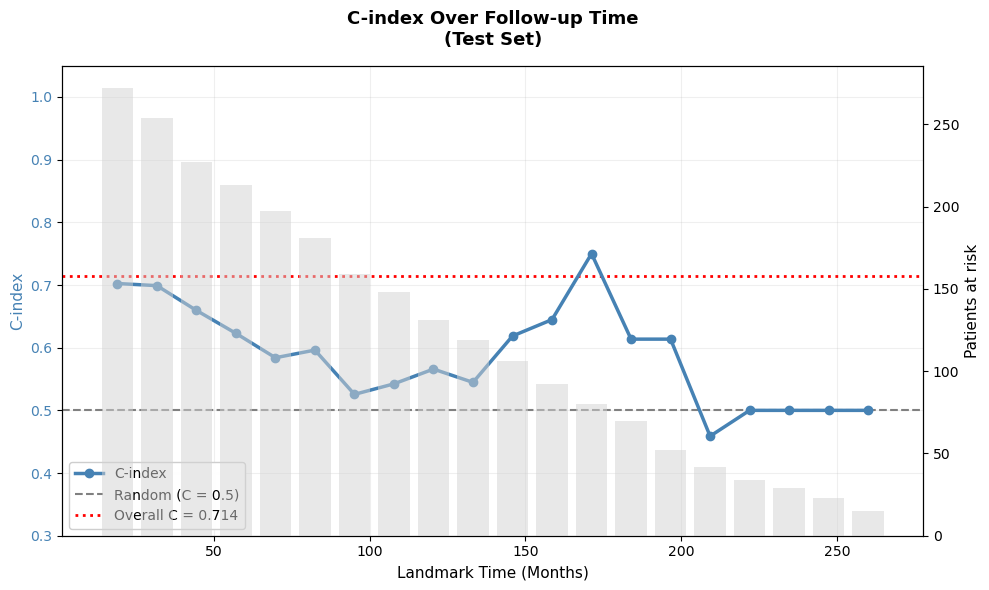

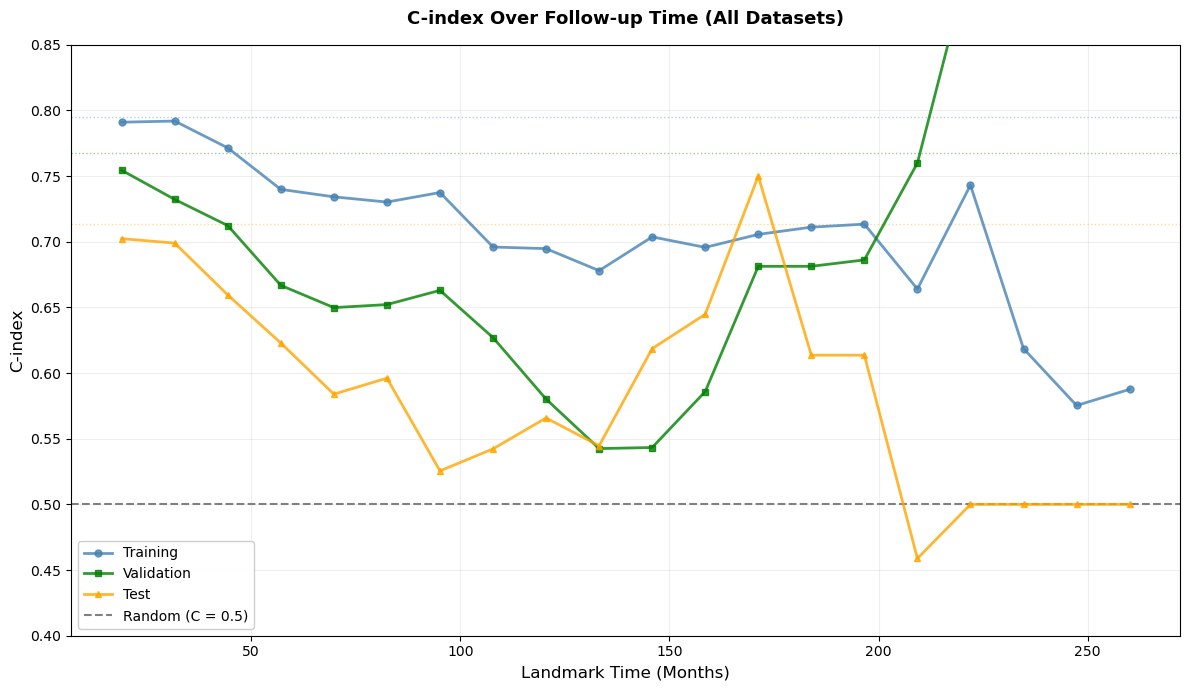


C-index Over Follow-up Time: Summary

Training Set:
  Mean C-index: 0.7042
  Std C-index:  0.0572
  Min C-index:  0.5753
  Max C-index:  0.7919
  Overall:      0.7951

Validation Set:
  Mean C-index: 0.6727
  Std C-index:  0.0882
  Min C-index:  0.5425
  Max C-index:  0.9167
  Overall:      0.7680

Test Set:
  Mean C-index: 0.5871
  Std C-index:  0.0773
  Min C-index:  0.4588
  Max C-index:  0.7500
  Overall:      0.7139


In [156]:
"""
Plot C-index (concordance index) over follow-up time using landmark analysis.

This shows how the model's discriminative ability changes as follow-up time increases.
Includes reference lines (random model, overall C-index) and patients-at-risk bar chart.
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
from lifelines.utils import concordance_index


# ── Generate risk predictions ──────────────────────────────────
model_surv_ae.eval()
with torch.no_grad():
    train_risk = model_surv_ae(X_train_tensor, expr_train_tensor).numpy().flatten()
    val_risk = model_surv_ae(X_val_tensor, expr_val_tensor).numpy().flatten()
    test_risk = model_surv_ae(X_test_tensor, expr_test_tensor).numpy().flatten()


# ── Landmark analysis: C-index over follow-up time ──────────────
def compute_cindex_over_landmarks(risk_scores, times, events, landmark_times=None):
    """
    Compute C-index at different landmark times.
    
    At each landmark time t, we evaluate the model's ability to discriminate
    among patients who are still at risk at time t.
    
    Args:
        risk_scores: predicted risk scores
        times: event times
        events: event indicators (1 = event, 0 = censored)
        landmark_times: specific landmark times to evaluate at
                       (default: deciles of follow-up time)
    
    Returns:
        landmark_times: timepoints evaluated
        c_indices: C-index at each landmark
        n_at_risk: number of patients at risk at each landmark
    """
    
    if landmark_times is None:
        # Use deciles of follow-up time as landmarks
        landmark_times = np.percentile(times, np.linspace(10, 90, 15))
    
    c_indices = []
    n_at_risk_list = []
    
    for t in landmark_times:
        # Identify patients at risk at time t (haven't had event/censoring yet)
        at_risk_mask = times >= t
        
        if at_risk_mask.sum() < 10:  # Skip if too few patients at risk
            continue
        
        # Compute C-index among those at risk
        try:
            c_idx = concordance_index(
                event_times=times[at_risk_mask],
                predicted_scores=-risk_scores[at_risk_mask],  # negative because lower risk = better
                event_observed=events[at_risk_mask]
            )
            c_indices.append(c_idx)
            n_at_risk_list.append(at_risk_mask.sum())
        except:
            continue
    
    return landmark_times[:len(c_indices)], np.array(c_indices), np.array(n_at_risk_list)


# ── Compute C-index trajectories ───────────────────────────────
# Use common landmark times across all datasets for consistency
all_times = np.concatenate([time_train, time_val, time_test])
common_landmarks = np.linspace(
    np.percentile(all_times, 5),
    np.percentile(all_times, 95),
    20
)

print("Computing C-index over follow-up time...")

landmarks_train, cindex_train, n_at_risk_train = compute_cindex_over_landmarks(
    train_risk, time_train, event_train, common_landmarks
)

landmarks_val, cindex_val, n_at_risk_val = compute_cindex_over_landmarks(
    val_risk, time_val, event_val, common_landmarks
)

landmarks_test, cindex_test, n_at_risk_test = compute_cindex_over_landmarks(
    test_risk, time_test, event_test, common_landmarks
)

print(f"  Training: {len(landmarks_train)} landmarks")
print(f"  Validation: {len(landmarks_val)} landmarks")
print(f"  Test: {len(landmarks_test)} landmarks")


# ── Compute overall C-index (across entire follow-up) ──────────
overall_cindex_train = concordance_index(
    event_times=time_train,
    predicted_scores=-train_risk,
    event_observed=event_train
)

overall_cindex_val = concordance_index(
    event_times=time_val,
    predicted_scores=-val_risk,
    event_observed=event_val
)

overall_cindex_test = concordance_index(
    event_times=time_test,
    predicted_scores=-test_risk,
    event_observed=event_test
)

print(f"\nOverall C-index:")
print(f"  Training: {overall_cindex_train:.4f}")
print(f"  Validation: {overall_cindex_val:.4f}")
print(f"  Test: {overall_cindex_test:.4f}")


# ── Plot C-index over follow-up time (single plot) ──────────────
def plot_cindex_over_time_single(landmarks, cindex, n_at_risk, overall_cindex,
                                 dataset_name="Test", figsize=(10, 6)):
    """
    Plot C-index over follow-up time with reference lines and at-risk bars.
    
    Mimics the structure of the uploaded image.
    """
    
    fig, ax1 = plt.subplots(figsize=figsize, facecolor='white')
    
    # ── Left y-axis: C-index ──────────────────────────────────
    ax1.set_xlabel("Landmark Time (Months)", fontsize=11)
    ax1.set_ylabel("C-index", fontsize=11, color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')
    ax1.set_ylim([0.3, 1.05])
    
    # Plot C-index trajectory
    ax1.plot(landmarks, cindex, marker='o', linewidth=2.5, markersize=6,
             color='steelblue', label='C-index', zorder=5)
    
    # Reference lines on left axis
    ax1.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5,
                label='Random (C = 0.5)', zorder=3)
    ax1.axhline(y=overall_cindex, color='red', linestyle=':', linewidth=2,
                label=f'Overall C = {overall_cindex:.3f}', zorder=3)
    
    # ── Right y-axis: Patients at risk ────────────────────────
    ax2 = ax1.twinx()
    ax2.set_ylabel("Patients at risk", fontsize=11, color='black')
    ax2.tick_params(axis='y', labelcolor='black')
    
    # Bar chart of patients at risk
    bar_width = (landmarks[1] - landmarks[0]) * 0.8 if len(landmarks) > 1 else 10
    ax2.bar(landmarks, n_at_risk, width=bar_width, color='lightgray',
            alpha=0.5, zorder=1, edgecolor='none')
    
    # ── Formatting ────────────────────────────────────────────
    ax1.set_title(f"C-index Over Follow-up Time\n({dataset_name} Set)",
                  fontsize=13, fontweight='bold', pad=15)
    ax1.grid(True, alpha=0.2, axis='both')
    ax1.set_axisbelow(True)
    
    # Legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    ax1.legend(lines1, labels1, loc='lower left', fontsize=10, framealpha=0.95)
    
    plt.tight_layout()
    
    return fig, ax1, ax2


# Plot for each dataset
fig_train, ax1_train, ax2_train = plot_cindex_over_time_single(
    landmarks_train, cindex_train, n_at_risk_train, overall_cindex_train,
    dataset_name="Training"
)
plt.show()

fig_val, ax1_val, ax2_val = plot_cindex_over_time_single(
    landmarks_val, cindex_val, n_at_risk_val, overall_cindex_val,
    dataset_name="Validation"
)
plt.show()

fig_test, ax1_test, ax2_test = plot_cindex_over_time_single(
    landmarks_test, cindex_test, n_at_risk_test, overall_cindex_test,
    dataset_name="Test"
)
plt.show()


# ── Comparison plot: All three datasets together ────────────────
def plot_cindex_comparison_all_datasets(landmarks_train, cindex_train,
                                        landmarks_val, cindex_val,
                                        landmarks_test, cindex_test,
                                        overall_cindex_train, overall_cindex_val,
                                        overall_cindex_test,
                                        figsize=(12, 7)):
    """
    Plot C-index trajectories for training, validation, and test sets on same axes.
    """
    
    fig, ax = plt.subplots(figsize=figsize, facecolor='white')
    
    # Plot trajectories
    ax.plot(landmarks_train, cindex_train, marker='o', linewidth=2,
            markersize=5, color='steelblue', label='Training', alpha=0.8, zorder=4)
    ax.plot(landmarks_val, cindex_val, marker='s', linewidth=2,
            markersize=5, color='green', label='Validation', alpha=0.8, zorder=4)
    ax.plot(landmarks_test, cindex_test, marker='^', linewidth=2,
            markersize=5, color='orange', label='Test', alpha=0.8, zorder=4)
    
    # Reference lines
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5,
               label='Random (C = 0.5)', zorder=2)
    
    # Overall C-index reference lines (subtle)
    ax.axhline(y=overall_cindex_train, color='steelblue', linestyle=':',
               linewidth=1, alpha=0.4, zorder=2)
    ax.axhline(y=overall_cindex_val, color='green', linestyle=':',
               linewidth=1, alpha=0.4, zorder=2)
    ax.axhline(y=overall_cindex_test, color='orange', linestyle=':',
               linewidth=1, alpha=0.4, zorder=2)
    
    # Formatting
    ax.set_xlabel("Landmark Time (Months)", fontsize=12)
    ax.set_ylabel("C-index", fontsize=12)
    ax.set_title("C-index Over Follow-up Time (All Datasets)",
                 fontsize=13, fontweight='bold', pad=15)
    ax.set_ylim([0.4, 0.85])
    ax.grid(True, alpha=0.2, axis='both')
    ax.set_axisbelow(True)
    
    ax.legend(loc='lower left', fontsize=10, framealpha=0.95)
    
    plt.tight_layout()
    
    return fig, ax


fig_all, ax_all = plot_cindex_comparison_all_datasets(
    landmarks_train, cindex_train,
    landmarks_val, cindex_val,
    landmarks_test, cindex_test,
    overall_cindex_train, overall_cindex_val, overall_cindex_test
)
plt.show()


# ── Summary statistics ─────────────────────────────────────────
print("\n" + "="*70)
print("C-index Over Follow-up Time: Summary")
print("="*70)

print(f"\nTraining Set:")
print(f"  Mean C-index: {cindex_train.mean():.4f}")
print(f"  Std C-index:  {cindex_train.std():.4f}")
print(f"  Min C-index:  {cindex_train.min():.4f}")
print(f"  Max C-index:  {cindex_train.max():.4f}")
print(f"  Overall:      {overall_cindex_train:.4f}")

print(f"\nValidation Set:")
print(f"  Mean C-index: {cindex_val.mean():.4f}")
print(f"  Std C-index:  {cindex_val.std():.4f}")
print(f"  Min C-index:  {cindex_val.min():.4f}")
print(f"  Max C-index:  {cindex_val.max():.4f}")
print(f"  Overall:      {overall_cindex_val:.4f}")

print(f"\nTest Set:")
print(f"  Mean C-index: {cindex_test.mean():.4f}")
print(f"  Std C-index:  {cindex_test.std():.4f}")
print(f"  Min C-index:  {cindex_test.min():.4f}")
print(f"  Max C-index:  {cindex_test.max():.4f}")
print(f"  Overall:      {overall_cindex_test:.4f}")

# Diagnostic on why low-risk groups maintain a high predicted survival probabiltiy over time 

DIAGNOSTIC 2: PyTorch Survival-Aware Autoencoder Analysis

[1] RISK SCORE DISTRIBUTION
--------------------------------------------------------------------------------

Training:
  Mean:    -0.5890
  Std:     0.9282
  Min:     -3.9011
  Max:     1.9142
  Range:   5.8153
  Median:  -0.6300
  IQR:     1.3468
  Skewness: 0.0072

Validation:
  Mean:    -0.6178
  Std:     0.9323
  Min:     -2.4080
  Max:     1.6707
  Range:   4.0787
  Median:  -0.6951
  IQR:     1.4720
  Skewness: 0.1555

Test:
  Mean:    -0.5171
  Std:     0.8463
  Min:     -3.1553
  Max:     1.5970
  Range:   4.7523
  Median:  -0.5416
  IQR:     1.2635
  Skewness: -0.0469

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
⚠️  CRITICAL CHECK: Range and Spread
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
✓ Risk score range adequate (>1.0)

[2] EVENT RATE CALIBRATION BY RISK QUINTILE
----------------------------------------------------------------------------

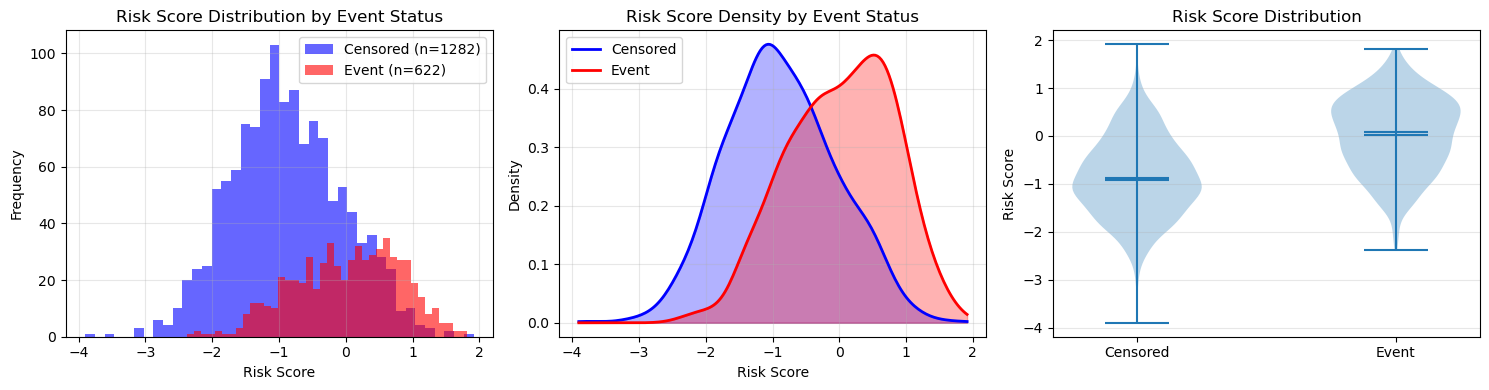


Mann-Whitney U test (risk score difference between event/censored):
  p-value: 0.000000
  ✓ Risk scores significantly differ between event/censored

[5] MODEL DISCRIMINATION (C-INDEX)
--------------------------------------------------------------------------------
Training    : C-index = 0.7951
Validation  : C-index = 0.7680
Test        : C-index = 0.7139

[6] LOW-RISK GROUP DEEP DIVE (Q1)
--------------------------------------------------------------------------------

Total Q1 patients: 381
Q1 events: 25
Q1 event rate: 6.6%
Q1 median follow-up: 147.8 months

Event timing in Q1:
  Median event time (when event occurred): 91.7 months
  Mean event time: 108.1 months
  Min event time: 20.0 months
  Median censored time: 151.1 months
  Mean censored time: 159.1 months

[7] RISK SCORE SEPARATION (Cohen's d)
--------------------------------------------------------------------------------
Q1 (Lowest) vs Q2:
  Cohen's d: 2.5396
  p-value: 1.22e-160
  Interpretation: Large effect
Q2 vs Q3:
  

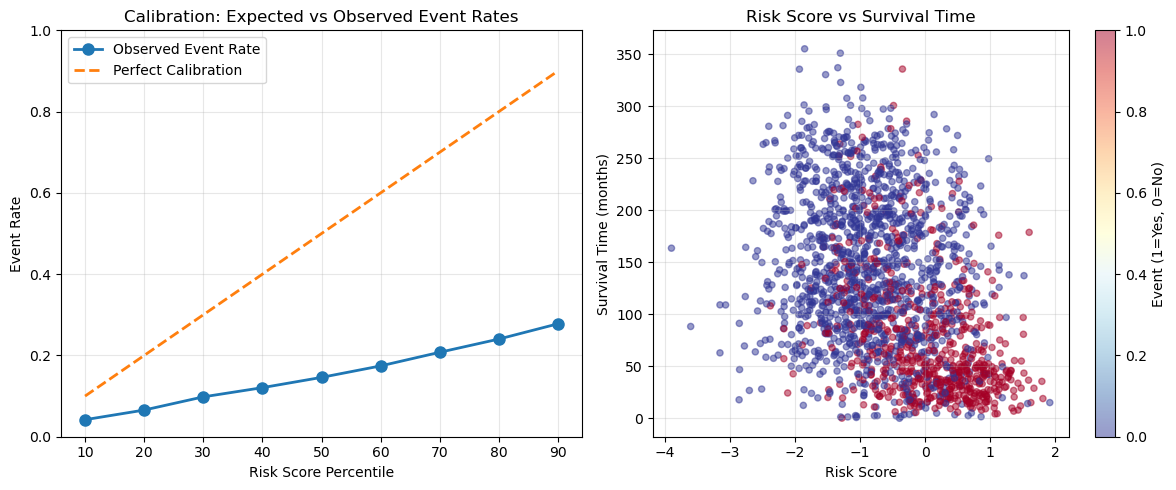


[9] OVERALL EVENT STATISTICS
--------------------------------------------------------------------------------
Total patients: 1904
Total events: 622 (32.7%)
Total censored: 1282 (67.3%)
Median follow-up: 115.6 months

SUMMARY: Why do low-risk groups maintain high survival?

Possible explanations:

1. WEAK RISK DISCRIMINATION:
   - Model may not be differentiating patients effectively
   - Check: C-index (should be >0.6), risk score range, event rate monotonicity

2. SHORTER FOLLOW-UP IN LOW-RISK GROUPS:
   - If low-risk patients have shorter median follow-up time,
     fewer events = higher survival curves
   - Check: Median follow-up times by group

3. SELECTION BIAS IN TRAINING:
   - If the model was trained with certain bias toward keeping low-risk
     groups censored longer (censoring informative)
   - Check: Follow-up time distribution by risk group

4. EXCELLENT MODEL CALIBRATION:
   - If model truly identifies lowest-risk patients well
   - Should verify with external data
   

In [151]:
"""
DIAGNOSTIC SCRIPT 2: PyTorch Survival-Aware Autoencoder
========================================================

Analyzes why low-risk groups maintain high survival probability.

Key metrics:
- Risk score distribution (range, spread)
- Hazard ratio calibration
- Separation between risk groups
- Model overconfidence in low-risk predictions
- Survival probability vs. risk score correlation
"""

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from lifelines.utils import concordance_index

print("="*80)
print("DIAGNOSTIC 2: PyTorch Survival-Aware Autoencoder Analysis")
print("="*80)

# Generate risk predictions
model_surv_ae.eval()
with torch.no_grad():
    train_risk = model_surv_ae(X_train_tensor, expr_train_tensor).numpy().flatten()
    val_risk = model_surv_ae(X_val_tensor, expr_val_tensor).numpy().flatten()
    test_risk = model_surv_ae(X_test_tensor, expr_test_tensor).numpy().flatten()
    all_risk = model_surv_ae(X_all_tensor, expr_all_tensor).numpy().flatten()

# ── 1. Risk Score Distribution ──────────────────────────────────
print("\n[1] RISK SCORE DISTRIBUTION")
print("-" * 80)

for name, risk, times, events in [
    ("Training", train_risk, time_train, event_train),
    ("Validation", val_risk, time_val, event_val),
    ("Test", test_risk, time_test, event_test),
]:
    print(f"\n{name}:")
    print(f"  Mean:    {risk.mean():.4f}")
    print(f"  Std:     {risk.std():.4f}")
    print(f"  Min:     {risk.min():.4f}")
    print(f"  Max:     {risk.max():.4f}")
    print(f"  Range:   {risk.max() - risk.min():.4f}")
    print(f"  Median:  {np.median(risk):.4f}")
    print(f"  IQR:     {np.percentile(risk, 75) - np.percentile(risk, 25):.4f}")
    
    skewness = stats.skew(risk)
    print(f"  Skewness: {skewness:.4f}")

# ⚠️ WARNING CHECK
print("\n" + "!"*80)
print("⚠️  CRITICAL CHECK: Range and Spread")
print("!"*80)
if (all_risk.max() - all_risk.min()) < 0.1:
    print("⚠️  CRITICAL: Risk score range < 0.1")
    print("   Your model may have weak risk discrimination!")
elif (all_risk.max() - all_risk.min()) < 1.0:
    print("⚠️  WARNING: Risk score range < 1.0")
    print("   Limited spread - may reduce discrimination between groups")
else:
    print("✓ Risk score range adequate (>1.0)")

# ── 2. Event Rate by Risk Group ─────────────────────────────────
print("\n[2] EVENT RATE CALIBRATION BY RISK QUINTILE")
print("-" * 80)

df_all = pd.DataFrame({
    'risk': all_risk,
    'time': time_all,
    'event': event_all,
    'dataset': ['train']*len(train_risk) + ['val']*len(val_risk) + ['test']*len(test_risk)
})

df_all['risk_group'] = pd.qcut(
    df_all['risk'],
    q=5,
    labels=["Q1 (Lowest)", "Q2", "Q3", "Q4", "Q5 (Highest)"],
    duplicates='drop'
)

print("\nEvent rates by quintile (FULL DATA):")
print("(If well-calibrated, should increase monotonically)")

event_rates_pytorch = []
for group in sorted(df_all['risk_group'].unique()):
    mask = df_all['risk_group'] == group
    n = mask.sum()
    events = df_all.loc[mask, 'event'].sum()
    rate = events / n
    median_time = df_all.loc[mask, 'time'].median()
    median_risk = df_all.loc[mask, 'risk'].median()
    
    print(f"\n{group}:")
    print(f"  n = {n}")
    print(f"  events = {events} ({rate:.1%})")
    print(f"  median time = {median_time:.1f} months")
    print(f"  median risk_score = {median_risk:.6f}")
    
    event_rates_pytorch.append(rate)

# Check monotonicity
is_monotonic = all(event_rates_pytorch[i] <= event_rates_pytorch[i+1] 
                   for i in range(len(event_rates_pytorch)-1))
if not is_monotonic:
    print("\n  ⚠️  WARNING: Event rates NOT monotonically increasing!")
    print("     This indicates poor calibration")
else:
    print("\n  ✓ Event rates increase monotonically (good calibration)")

# ── 3. Hazard Ratio Analysis ────────────────────────────────────
print("\n[3] RELATIVE HAZARD BETWEEN RISK GROUPS")
print("-" * 80)

print("\nRisk scores by quintile (should increase):")
for group in sorted(df_all['risk_group'].unique()):
    mask = df_all['risk_group'] == group
    risks = df_all.loc[mask, 'risk'].values
    print(f"{group}: mean={risks.mean():.6f} | min={risks.min():.6f} | max={risks.max():.6f}")

# Calculate hazard ratios (assuming Cox model: hazard ∝ exp(risk))
print("\nRelative Hazards (assuming exp(risk) ∝ hazard):")
q1_mean_risk = df_all.loc[df_all['risk_group'] == "Q1 (Lowest)", 'risk'].mean()
for group in sorted(df_all['risk_group'].unique()):
    mask = df_all['risk_group'] == group
    mean_risk = df_all.loc[mask, 'risk'].mean()
    relative_hazard = np.exp(mean_risk - q1_mean_risk)
    print(f"{group}: {relative_hazard:.4f}x")

# ── 4. Risk Score vs Event Outcome Distribution ──────────────────
print("\n[4] RISK DISTRIBUTION BY EVENT STATUS")
print("-" * 80)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram (all data)
ax = axes[0]
ax.hist(df_all.loc[df_all['event'] == 0, 'risk'], 
        bins=40, alpha=0.6, label=f"Censored (n={int((df_all['event']==0).sum())})", 
        color='blue')
ax.hist(df_all.loc[df_all['event'] == 1, 'risk'], 
        bins=40, alpha=0.6, label=f"Event (n={int((df_all['event']==1).sum())})", 
        color='red')
ax.set_xlabel("Risk Score")
ax.set_ylabel("Frequency")
ax.set_title("Risk Score Distribution by Event Status")
ax.legend()
ax.grid(True, alpha=0.3)

# KDE plot for better visualization
ax = axes[1]
from scipy.stats import gaussian_kde
censored_risks = df_all.loc[df_all['event'] == 0, 'risk'].values
event_risks = df_all.loc[df_all['event'] == 1, 'risk'].values

if len(censored_risks) > 1 and len(event_risks) > 1:
    x_range = np.linspace(df_all['risk'].min(), df_all['risk'].max(), 200)
    
    kde_censored = gaussian_kde(censored_risks)
    kde_event = gaussian_kde(event_risks)
    
    ax.plot(x_range, kde_censored(x_range), label='Censored', linewidth=2, color='blue')
    ax.plot(x_range, kde_event(x_range), label='Event', linewidth=2, color='red')
    ax.fill_between(x_range, kde_censored(x_range), alpha=0.3, color='blue')
    ax.fill_between(x_range, kde_event(x_range), alpha=0.3, color='red')
    ax.set_xlabel("Risk Score")
    ax.set_ylabel("Density")
    ax.set_title("Risk Score Density by Event Status")
    ax.legend()
    ax.grid(True, alpha=0.3)

# Violin plot
ax = axes[2]
data_violin = [
    df_all.loc[df_all['event'] == 0, 'risk'].values,
    df_all.loc[df_all['event'] == 1, 'risk'].values
]
parts = ax.violinplot(data_violin, positions=[0, 1], showmeans=True, showmedians=True)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Censored', 'Event'])
ax.set_ylabel("Risk Score")
ax.set_title("Risk Score Distribution")
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Statistical test
from scipy.stats import mannwhitneyu
stat, p_value = mannwhitneyu(event_risks, censored_risks)
print(f"\nMann-Whitney U test (risk score difference between event/censored):")
print(f"  p-value: {p_value:.6f}")
if p_value < 0.05:
    print("  ✓ Risk scores significantly differ between event/censored")
else:
    print("  ⚠️  Risk scores NOT significantly different!")

# ── 5. C-index and Discrimination ───────────────────────────────
print("\n[5] MODEL DISCRIMINATION (C-INDEX)")
print("-" * 80)

for name, risk, times, events in [
    ("Training", train_risk, time_train, event_train),
    ("Validation", val_risk, time_val, event_val),
    ("Test", test_risk, time_test, event_test),
]:
    c_idx = concordance_index(times, -risk, events)
    print(f"{name:12}: C-index = {c_idx:.4f}")

# ── 6. Low-Risk Patient Survival Analysis ───────────────────────
print("\n[6] LOW-RISK GROUP DEEP DIVE (Q1)")
print("-" * 80)

q1_mask = df_all['risk_group'] == "Q1 (Lowest)"
q1_data = df_all[q1_mask]

print(f"\nTotal Q1 patients: {q1_mask.sum()}")
print(f"Q1 events: {q1_data['event'].sum()}")
print(f"Q1 event rate: {q1_data['event'].mean():.1%}")
print(f"Q1 median follow-up: {q1_data['time'].median():.1f} months")

# Why do low-risk patients survive longer?
print("\nEvent timing in Q1:")
q1_events = q1_data[q1_data['event'] == 1]
if len(q1_events) > 0:
    print(f"  Median event time (when event occurred): {q1_events['time'].median():.1f} months")
    print(f"  Mean event time: {q1_events['time'].mean():.1f} months")
    print(f"  Min event time: {q1_events['time'].min():.1f} months")
else:
    print("  No events in Q1!")

q1_censored = q1_data[q1_data['event'] == 0]
if len(q1_censored) > 0:
    print(f"  Median censored time: {q1_censored['time'].median():.1f} months")
    print(f"  Mean censored time: {q1_censored['time'].mean():.1f} months")

# ── 7. Risk Score Separation Between Groups ─────────────────────
print("\n[7] RISK SCORE SEPARATION (Cohen's d)")
print("-" * 80)

from scipy.stats import ttest_ind

groups = sorted(df_all['risk_group'].unique())
for i in range(len(groups)-1):
    g1, g2 = groups[i], groups[i+1]
    
    risks_g1 = df_all.loc[df_all['risk_group'] == g1, 'risk'].values
    risks_g2 = df_all.loc[df_all['risk_group'] == g2, 'risk'].values
    
    # Cohen's d
    pooled_std = np.sqrt((risks_g1.std()**2 + risks_g2.std()**2) / 2)
    cohens_d = (risks_g2.mean() - risks_g1.mean()) / pooled_std
    
    # T-test
    t_stat, p_val = ttest_ind(risks_g1, risks_g2)
    
    print(f"{g1} vs {g2}:")
    print(f"  Cohen's d: {cohens_d:.4f}")
    print(f"  p-value: {p_val:.2e}")
    print(f"  Interpretation: {'Large' if cohens_d > 0.8 else 'Medium' if cohens_d > 0.5 else 'Small'} effect")

# ── 8. Calibration Plot ─────────────────────────────────────────
print("\n[8] CALIBRATION: Expected vs Observed Event Rates")
print("-" * 80)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Event rate vs. risk score percentile
ax = axes[0]
percentiles = np.linspace(0, 100, 11)[1:-1]
percentile_risks = np.percentile(all_risk, percentiles)

observed_event_rates = []
for risk_thresh in percentile_risks:
    mask = all_risk <= risk_thresh
    if mask.sum() > 0:
        event_rate = event_all[mask].mean()
        observed_event_rates.append(event_rate)

ax.plot(percentiles, observed_event_rates, marker='o', linewidth=2, 
        markersize=8, label='Observed Event Rate')
ax.plot(percentiles, percentiles/100, '--', linewidth=2, label='Perfect Calibration')
ax.set_xlabel("Risk Score Percentile")
ax.set_ylabel("Event Rate")
ax.set_title("Calibration: Expected vs Observed Event Rates")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

# Plot 2: Risk score vs survival time
ax = axes[1]
scatter = ax.scatter(all_risk, time_all, c=event_all, cmap='RdYlBu_r', 
                     alpha=0.5, s=20)
ax.set_xlabel("Risk Score")
ax.set_ylabel("Survival Time (months)")
ax.set_title("Risk Score vs Survival Time")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Event (1=Yes, 0=No)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── 9. Summary Statistics ──────────────────────────────────────
print("\n[9] OVERALL EVENT STATISTICS")
print("-" * 80)

total_patients = len(df_all)
total_events = event_all.sum()
total_censored = total_patients - total_events
event_rate = total_events / total_patients

print(f"Total patients: {total_patients}")
print(f"Total events: {total_events} ({event_rate:.1%})")
print(f"Total censored: {total_censored} ({(1-event_rate):.1%})")
print(f"Median follow-up: {np.median(time_all):.1f} months")

print("\n" + "="*80)
print("SUMMARY: Why do low-risk groups maintain high survival?")
print("="*80)
print("""
Possible explanations:

1. WEAK RISK DISCRIMINATION:
   - Model may not be differentiating patients effectively
   - Check: C-index (should be >0.6), risk score range, event rate monotonicity
   
2. SHORTER FOLLOW-UP IN LOW-RISK GROUPS:
   - If low-risk patients have shorter median follow-up time,
     fewer events = higher survival curves
   - Check: Median follow-up times by group
   
3. SELECTION BIAS IN TRAINING:
   - If the model was trained with certain bias toward keeping low-risk
     groups censored longer (censoring informative)
   - Check: Follow-up time distribution by risk group
   
4. EXCELLENT MODEL CALIBRATION:
   - If model truly identifies lowest-risk patients well
   - Should verify with external data
   - Check: Does Q1 have significantly lower event rate?
   
5. DIFFERENT MODEL ARCHITECTURE:
   - PyTorch model uses both clinical + expression data
   - Lifelines model may use different feature set
   - Different models → different risk orderings
   - Check: Which variables are most important in each model?
   
6. COMPETING RISKS:
   - If different causes of death, model may prioritize differently
   - Check: Are all deaths due to same cause?
""")